<a href="https://colab.research.google.com/github/PepeFederico/Progetto_Mercati_Finanziari/blob/main/rendimenti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Progetto Metodi Probabilistici e Statistici per Mercati Finanziari**
#1 Abstract
Lo scopo del presente progetto è applicare modelli di Deep Learning ai mercati finanziari, al fine di sviluppare un sistema predittivo capace di stimare i rendimenti futuri basandosi sullo storico dei dati passati, estratti dal paniere dei titoli dello S&P 500. Saranno inoltre testate eventuali altre soluzioni, in grado di permettere un'integrazione e comprensione su come integrare i modelli ML nell'ambito finanziario.
Il lavoro documenta l'intero ciclo di sviluppo del modello quantitativo, articolandosi nei seguenti punti principali:

* **Raccolta dei dati**: il processo di estrazione delle serie storiche tramite API finanziarie.

* **Pre-processing e Feature Engineering**: la trasformazione dei prezzi storici in rendimenti logaritmici e la strutturazione di finestre temporali sincrone su più timeframe.

* **Architettura del modello**: la progettazione di una rete neurale ricorrente (LSTM) multi-input.

* **Backtesting e Validazione**: la verifica delle performance su dati out-of-sample (mai visti dal modello) e l'analisi statistica dei risultati e dei residui per valutarne la reale robustezza ed efficacia operativa.

In [1]:
# Import delle librerie
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#2. Fase di raccolta Dati
In questa fase, ci occupiamo di raccogliere i dati, mediante il repository di *Yahoo Finance*. Per costringere la rete a catturare dinamiche macroeconomiche e interconnessioni cross-asset, il paniere, preso dal mercato **S&P500** è stato composto selezionando aziende leader a grande capitalizzazione, diversificate tra i principali settori dell'economia statunitense: come:
* **Tecnologia**: Scelta l'azienda *NVIDIA Corporation*
* **Servizi di Comunicazione**: Scelta l'azienda *Alphabet Inc.* (Google)
* **Beni di Consumo**: Scelte le aziende *Amazon.com, Inc.* e *Walmart Inc.*
* **Finanziario**: Scelta l'azienda *Berkshire Hathaway*
* **Salute e Sanità**: Scelta l'azienda *Eli Lilly and Company*
* **Energia**: Scelta l'azienda *Exxon Mobil Corp.*

Nel presente studio si è scelto di utilizzare i rendimenti logaritmici in sostituzione dei rendimenti percentuali semplici. Il calcolo di questi ultimi segue infatti la seguente formula:

$$R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$$

Dove:
* $R_t$ rappresenta il rendimento percentuale semplice al tempo $t$.
* $P_t$ è il prezzo di chiusura corrente al tempo $t$.
* $P_{t-1}$ è il prezzo di chiusura al tempo precedente $t-1$.

I rendimenti logaritmici, invece, vengono calcolati applicando la seguente formula:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right) = \ln(P_t) - \ln(P_{t-1})$$

Dove:
* $r_t$ rappresenta il rendimento logaritmico al tempo $t$.
* $P_t$ è il prezzo di chiusura dell'asset al tempo corrente $t$.
* $P_{t-1}$ è il prezzo di chiusura dell'asset al tempo precedente $t-1$.
* $\ln$ indica il logaritmo naturale.

L'adozione dei rendimenti logaritmici rispetto a quelli semplici offre tre vantaggi teorici e computazionali strategici per l'addestramento di reti neurali ricorrenti:

1. **Additività temporale:** A differenza dei rendimenti semplici, i rendimenti logaritmici possono essere sommati linearmente nel tempo. Il log-return di un intero periodo (es. 5 giorni o un trimestre) è matematicamente equivalente alla somma dei log-return dei singoli giorni che lo compongono, garantendo coerenza analitica nelle finestre mobili (*sliding windows*).
2. **Stazionarietà delle serie storiche:** I prezzi grezzi delle azioni presentano trend di lungo periodo non stazionari che ostacolano la convergenza degli algoritmi di ottimizzazione. La trasformazione in log-returns stabilizza la varianza e rimuove il trend.
3. **Simmetria distributiva:** I rendimenti percentuali sono asimmetrici poiché limitati inferiormente al $-100\%$ (un'azione non può valere meno di zero). I rendimenti logaritmici mappano l'intervallo dei prezzi su una scala simmetrica che spazia teoricamente da $-\infty$ a $+\infty$, avvicinando la distribuzione a una normale e facilitando il calcolo della funzione di perdita (*Loss Function*).

In [ ]:
# 1. Definiamo i 7 titoli
tickers = ['NVDA', 'GOOGL', 'AMZN', 'BRK-B', 'LLY', 'WMT', 'XOM']

# 2. Scarichiamo i dati (10 anni come da parametro, non 2)
print("Scaricamento dati in corso...")
df_raw = yf.download(tickers, period='2y', interval='1d')

# Estrazione sicura dei prezzi di chiusura (gestisce il multi-index di yfinance)
if isinstance(df_raw.columns, pd.MultiIndex):
    data = df_raw['Close']
else:
    data = df_raw

# Trasforma i prezzi in logaritmici
log_data = np.log(data)

# --- 3. CREAZIONE DEI TASSI CON FINESTRE SCORREVOLI ---

# A. Giornaliero (finestra = 1 giorno)
dataset_rendimenti_giornalieri = log_data.diff(1)

# B. Settimanale rolling (finestra = 5 giorni lavorativi)
dataset_rendimenti_settimanali_sliding_window = log_data.diff(5)

# B.1. Settimanale tumbling (passo = 1 settimana) -> Riallineato subito al calendario giornaliero
data_weekly = data.resample('W').last()
returns_1w = np.log(data_weekly).diff(1)
dataset_rendimenti_settimanali_tumbling_window = returns_1w.reindex(log_data.index).ffill()

# C. Mensile rolling (finestra = 21 giorni lavorativi)
dataset_rendimenti_settimanali_mensili = log_data.diff(21)

# D. Trimestrale rolling (finestra = 63 giorni lavorativi)
dataset_rendimenti_settimanali_trimestrali = log_data.diff(63)

# 4. Rinominiamo le colonne in modo esplicito e sicuro per Pandas
dataset_rendimenti_giornalieri.columns                    = [f"{col}_Ret_1D"      for col in dataset_rendimenti_giornalieri.columns]
dataset_rendimenti_settimanali_sliding_window.columns     = [f"{col}_Ret_5D_Roll" for col in dataset_rendimenti_settimanali_sliding_window.columns]
dataset_rendimenti_settimanali_tumbling_window.columns    = [f"{col}_Ret_1W_Tumb" for col in dataset_rendimenti_settimanali_tumbling_window.columns]
dataset_rendimenti_settimanali_mensili.columns            = [f"{col}_Ret_1M"      for col in dataset_rendimenti_settimanali_mensili.columns]
dataset_rendimenti_settimanali_trimestrali.columns        = [f"{col}_Ret_3M"      for col in dataset_rendimenti_settimanali_trimestrali.columns]

# 5. Uniamo tutto nel dataset globale
dataset_finale = pd.concat([
    dataset_rendimenti_giornalieri,
    dataset_rendimenti_settimanali_sliding_window,
    dataset_rendimenti_settimanali_tumbling_window,
    dataset_rendimenti_settimanali_mensili,
    dataset_rendimenti_settimanali_trimestrali
], axis=1)


# --- 7. SALVATAGGIO IN CSV AUTOMATIZZATO ---
# Dizionario per mappare il nome del file al rispettivo DataFrame corretto
files_to_save = {
    "rendimenti_multi_timeframe.csv": dataset_finale,
    "rendimenti_giornalieri.csv": dataset_rendimenti_giornalieri,
    "rendimenti_settimanali_tumbling.csv": dataset_rendimenti_settimanali_tumbling_window,
    "rendimenti_settimanali_sliding.csv": dataset_rendimenti_settimanali_sliding_window,
    "rendimenti_mensili.csv": dataset_rendimenti_settimanali_mensili,
    "rendimenti_trimestrali.csv": dataset_rendimenti_settimanali_trimestrali
}

for filename, df in files_to_save.items():
    df.to_csv(filename)
    print(f"Dati estratti e salvati in: {filename:<35} | Dimensioni: {df.shape}")

Scaricamento dati in corso...


/tmp/ipykernel_624/2051934083.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_raw = yf.download(tickers, period='2y', interval='1d')
[*********************100%***********************]  7 of 7 completed

Dati estratti e salvati in: rendimenti_multi_timeframe.csv      | Dimensioni: (501, 35)
Dati estratti e salvati in: rendimenti_giornalieri.csv          | Dimensioni: (501, 7)
Dati estratti e salvati in: rendimenti_settimanali_tumbling.csv | Dimensioni: (501, 7)
Dati estratti e salvati in: rendimenti_settimanali_sliding.csv  | Dimensioni: (501, 7)
Dati estratti e salvati in: rendimenti_mensili.csv              | Dimensioni: (501, 7)
Dati estratti e salvati in: rendimenti_trimestrali.csv          | Dimensioni: (501, 7)


In [ ]:
# --- STEP 1: FILTRO COLONNE (Teniamo SOLO Amazon) ---
# Selezioniamo solo la colonna di AMZN per ciascun orizzonte temporale
df_giornalieri = dataset_rendimenti_giornalieri[['AMZN_Ret_1D']].copy()
df_settimanali = dataset_rendimenti_settimanali_sliding_window[['AMZN_Ret_5D_Roll']].copy()
df_trimestrali = dataset_rendimenti_settimanali_trimestrali[['AMZN_Ret_3M']].copy()

# --- STEP 2: DEFINIZIONE DEL TARGET ---
# Prendiamo il rendimento settimanale di Amazon e lo shiftiamo di -1 (o -5 se vuoi mantenere il vecchio codice)
target_serie = df_settimanali['AMZN_Ret_5D_Roll'].shift(-1)

# --- STEP 3: UNIONE TEMPORALE E ALLINEAMENTO PERFETTO ---
# Fondiamo i tre rami (ciascuno con 1 sola colonna) e il target in un'unica tabella
df_sincro = pd.concat([df_giornalieri, df_settimanali, df_trimestrali, target_serie.rename('TARGET')], axis=1)

# Applichiamo la maschera temporale
df_sincro = df_sincro.loc['2016-09-15':]

# Pulizia dei NaN (elimina le teste vuote e le code del target shiftato)
df_sincro = df_sincro.dropna()

# --- STEP 4: ESTRAZIONE DELLE FINESTRE TEMPORALI (Lookback 3D con 1 sola Feature) ---
lookback_g = 20
lookback_s = 10
lookback_w = 6

max_lookback = max(lookback_g, lookback_s, lookback_w)

# Colonne (ora ognuna contiene SOLO la colonna di Amazon)
cols_g = df_giornalieri.columns
cols_s = df_settimanali.columns
cols_w = df_trimestrali.columns

X_g_list, X_s_list, X_w_list, y_list = [], [], [], []

# Ciclo di estrazione sincronizzato
for i in range(max_lookback, len(df_sincro)):
    y_list.append(df_sincro['TARGET'].iloc[i])

    # Finestre 3D (Formato: Lookback, 1 Feature)
    X_g_list.append(df_sincro[cols_g].iloc[i-lookback_g:i].values)
    X_s_list.append(df_sincro[cols_s].iloc[i-lookback_s:i].values)
    X_w_list.append(df_sincro[cols_w].iloc[i-lookback_w:i].values)

# Conversione in Array NumPy
X_3d_g = np.array(X_g_list)
X_3d_s = np.array(X_s_list)
X_3d_w = np.array(X_w_list)
y_target_sincro = np.array(y_list)


# --- STEP 5: SPLIT CRONOLOGICO (NO SHUFFLING) ---
total_samples = len(y_target_sincro)
split_test_idx = int(total_samples * 0.80)
split_val_idx = int(split_test_idx * 0.90)

# Split Ramo Giornaliero (Shape finale: [Campioni, 20, 1])
X_train_g, X_val_g, X_test_g = X_3d_g[:split_val_idx], X_3d_g[split_val_idx:split_test_idx], X_3d_g[split_test_idx:]

# Split Ramo Settimanale (Shape finale: [Campioni, 10, 1])
X_train_s, X_val_s, X_test_s = X_3d_s[:split_val_idx], X_3d_s[split_val_idx:split_test_idx], X_3d_s[split_test_idx:]

# Split Ramo Trimestrale (Shape finale: [Campioni, 6, 1])
X_train_w, X_val_w, X_test_w = X_3d_w[:split_val_idx], X_3d_w[split_val_idx:split_test_idx], X_3d_w[split_test_idx:]

# Split Target
y_train, y_val, y_test = y_target_sincro[:split_val_idx], y_target_sincro[split_val_idx:split_test_idx], y_target_sincro[split_test_idx:]

print(f"Shape finale Train Amazon Giornaliero: {X_train_g.shape} (Atteso: [Campioni, 20, 1])")
print(f"Shape finale Train Target:            {y_train.shape}")


Shape finale Train Amazon Giornaliero: (299, 20, 1) (Atteso: [Campioni, 20, 1])
Shape finale Train Target:            (299,)


#3. Perché utilizzare le reti LSTM? Il Ruolo della Memoria nel Rilevamento dei Trend

Le reti neurali tradizionali (*Feedforward*) considerano ogni input come indipendente dagli altri, rendendole inadatte per l'analisi finanziaria dove l'ordine cronologico è fondamentale. Le reti ricorrenti standard (*RNN*), d'altra parte, soffrono del problema del **gradiente che svanisce (Vanishing Gradient)**: man mano che la finestra temporale si allunga, dimenticano ciò che è accaduto nei primi passaggi.

Le **celle LSTM** risolvono questo limite matematico attraverso una struttura a due canali di memoria e un sistema di regolazione basato su tre porte (*gates*):

1. **La Memoria a Lungo Termine (Cell State - $C_t$):** Funziona come un nastro trasportatore che attraversa l'intera catena temporale. Modificata pochissimo da interazioni lineari, permette alle informazioni cruciali del passato remoto di viaggiare intatte per molte epoche. Nel nostro modello, questo canale permette alla rete di **isolare e mantenere il trend macroeconomico di fondo**, i cicli stagionali o i cambi strutturali di volatilità che si sviluppano su mesi o trimestri.
2. **La Memoria a Breve Termine (Hidden State - $h_t$):** È il vettore che contiene l'output della cella per il singolo *timestamp* corrente. Cattura le reazioni immediate del mercato, i micro-impulsi e i vettori di momentum giornalieri.

#### Il Meccanismo di Selezione: Scartare il Rumore, Generare il Segnale

La vera forza della LSTM risiede nella sua capacità di decidere matematicamente quanta memoria scartare e quanta generarne a ogni passo temporale. Questo avviene attraverso tre filtri (porte), fondamentali da descrivere per giustificare il comportamento del modello:

* **Forget Gate (Cosa scartare):** Analizza i nuovi rendimenti in entrata e decide quali vecchie informazioni memorizzate nel *Cell State* non sono più rilevanti. Nei mercati finanziari, questo serve a **"dimenticare" i vecchi trend ormai esauriti** o i picchi di volatilità anomali del passato che distorcerebbero le previsioni future.
* **Input Gate (Cosa generare):** Determina quali nuove informazioni provenienti dai rendimenti odierni sono abbastanza significative da essere integrate nella memoria a lungo termine. La rete decide se l'oscillazione odierna è solo rumore passeggero o l'inizio di un nuovo trend di fondo.
* **Output Gate (Cosa trasmettere):** Regola quanta parte della memoria a lungo termine accumulata debba essere trasmessa all'esterno come predizione attuale e passata alla cella successiva.

### Sinergia con l'Architettura Multi-Timeframe

È proprio grazie a questa doppia memoria che l'architettura a tre rami del nostro progetto ha senso:
* Il ramo **Trimestrale** e **Settimanale** stimolano la memoria a *lungo termine* della LSTM, costringendola a focalizzarsi sulla traiettoria macroeconomica e sulla persistenza del trend.
* Il ramo **Giornaliero** sfrutta la memoria a *breve termine*, permettendo alla rete di calibrare la predizione finale in base alle ultime deviazioni e agli shock di liquidità dell'ultima giornata di borsa.

#4. Architettura della Rete: Modello LSTM Multi-Input Multi-Timeframe

Per catturare la complessa dinamica temporale dei mercati finanziari, l'architettura proposta non si affida a un'unica sequenza lineare, ma si struttura come una rete neurale multi-input a tre rami paralleli.

L'architettura del modello si articola nelle seguenti componenti macro-strutturali:

1. **Ramo Giornaliero (Breve Termine):** Riceve in ingresso un tensore con dimensione $(20, 1)$, corrispondente alle ultime 20 giornate di borsa (circa un mese solare di contrattazioni). Questo blocco è elaborato da uno strato LSTM da 64 unità ad alta capacità, deputato a catturare i micro-impulsi, la volatilità recente e gli shock di liquidità a breve termine.
2. **Ramo Settimanale (Medio Termine):** Accetta un input con *lookback* pari a 10 step di rendimenti *sliding* settimanali (dimensione $(10, 1)$). Lo strato LSTM associato (32 unità) estrae i trend ciclici intermedi, isolando il *momentum* e le inversioni di tendenza che si sviluppano nell'arco di pochi mesi.
3. **Ramo Trimestrale (Lungo Termine):** Analizza la scomposizione macroeconomica di fondo attraverso una finestra di 6 trimestri mobili (dimensione $(6, 1)$). Data la bassa frequenza e l'alto contenuto di segnale pulito, viene elaborato da uno strato LSTM compatto da 16 unità, focalizzato esclusivamente sulla traiettoria strutturale del trend di fondo.


#### Fusione Latente e Decisione Finale

I vettori di caratteristiche estratti indipendentemente dalle tre LSTM vengono fusi orizzontalmente tramite un livello di concatenazione (`Concatenate`). Questo processo genera un unico vettore latente globale da 112 elementi ($64 + 32 + 16$), il quale racchiude l'informazione temporale sintetizzata di tutti e tre i *timeframe*.

Questo spazio multidimensionale viene successivamente convogliato verso i blocchi decisionali finali:
* **Strato Denso Intermedio (`Dense`):** Composto da 32 neuroni con funzione di attivazione non lineare **ReLU** (*Rectified Linear Unit*), con lo scopo di mappare le interazioni complesse e non lineari tra i trend di breve, medio e lungo periodo precedentemente concatenati.
* **Strato di Output (`Dense`):** Costituito da un singolo neurone con funzione di attivazione **lineare**. Trattandosi di un problema di regressione quantitativa pura (la stima puntuale del rendimento logaritmico futuro), l'attivazione lineare permette al modello di mappare liberamente l'output nell'intero dominio dei numeri reali ($-\infty, +\infty$), senza vincoli o schiacciamenti di scala.

Il modello viene infine compilato utilizzando l'ottimizzatore **Adam**, scelto per la sua capacità di adattare dinamicamente il tasso di apprendimento per ogni singolo parametro, e la funzione di perdita **MSE** (*Mean Squared Error*), che penalizza in modo quadratico gli errori di previsione più marcati, guidando la rete verso una configurazione stabile e conservativa.

In [ ]:
#   Costruzione della rete

# 1° Ramo: Giornaliero
input_giornaliero = Input(shape=(20, 1), name = "Input_Giornaliero")
lstm_giornaliero = LSTM(64, return_sequences = False)(input_giornaliero)

# 2° Ramo: Settimanale
input_settimanale = Input(shape=(10, 1), name='Input_Settimanale')
lstm_settimanale = LSTM(32, return_sequences=False)(input_settimanale)

#3° Ramo: Trimestrale
input_trimestrale = Input(shape=(6, 1), name='Input_Trimestrale')
lstm_trimestrale = LSTM(16, return_sequences=False)(input_trimestrale)

# Concatenazione Livelli
concatenato = Concatenate()([lstm_giornaliero, lstm_settimanale, lstm_trimestrale])

# Passiamo il vettore fuso a degli strati densi per la decisione finale
denso_1 = Dense(32, activation='relu')(concatenato)
# Strato di output: 1 solo neurone con attivazione lineare (perché è una regressione del rendimento)
output_finale = Dense(1, activation='linear', name='Output_Predizione')(denso_1)

model = Model(inputs=[input_giornaliero, input_settimanale, input_trimestrale], outputs=output_finale)

# Compilazione
model.compile(optimizer='adam', loss='mse')

# Mostra la struttura della rete
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_Giornaliero   │ (None, 20, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_Settimanale   │ (None, 10, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_Trimestrale   │ (None, 6, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     16,896 │ Input_Giornalier… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │      4,352 │ Input_Settimanal… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 16)        │      1,152 │ Input_Trimestral… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 112)       │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ lstm_1[0][0],     │
│                     │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      3,616 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output_Predizione   │ (None, 1)         │         33 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,049 (101.75 KB)

 Trainable params: 26,049 (101.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#   Addestramento modello

history = model.fit(
    x=[X_train_g, X_train_s, X_train_w],
    y=y_train,
    validation_data=([X_val_g, X_val_s, X_val_w], y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - loss: 0.0020 - val_loss: 0.0038
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0018 - val_loss: 0.0037
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0016 - val_loss: 0.0036
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0016 - val_loss: 0.0029
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0014 - val_loss: 0.0029
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0013 - val_loss: 0.0025
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0012 - val_loss: 0.0024
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0012 - val_loss: 0.0023
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0012 - val_loss: 0.0020
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0011 - val_loss: 0.0018
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0011 - val_loss: 0.0015
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step
--- METRICHE DI TEST (AMAZON SINGOLO ASSET) ---
Mean Absolute Error (MAE): 0.027469
Mean Squared Error (MSE):  0.001193
R² Score (Bontà del modello): 0.4395
-----------------------------------------------



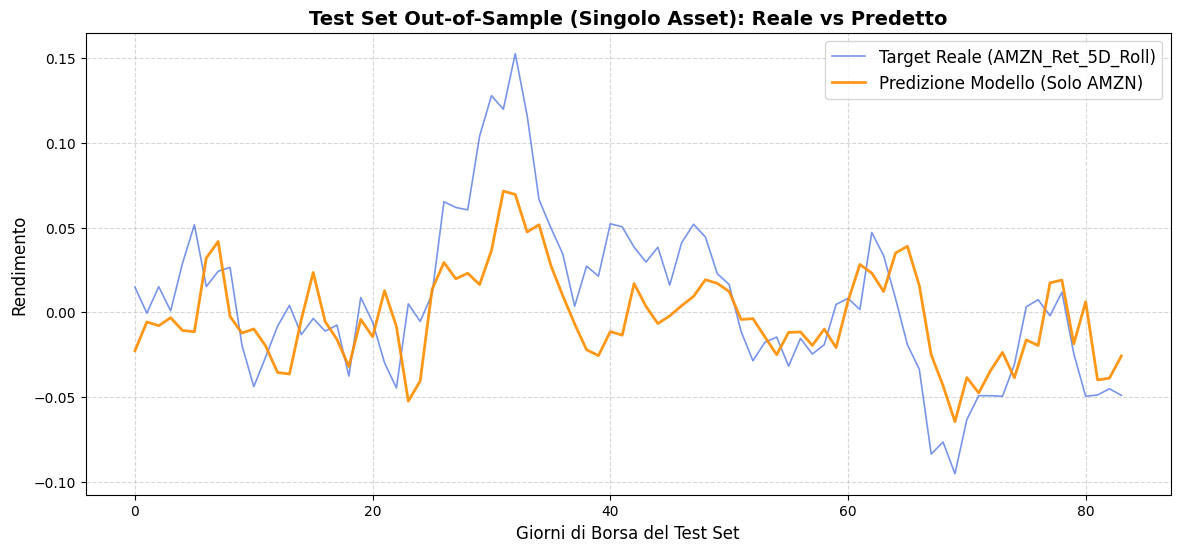

In [ ]:
# 1. Generazione delle predizioni sui dati di TEST (singolo asset)
y_pred = model.predict([X_test_g, X_test_s, X_test_w]).flatten()

# 2. Calcolo delle metriche di errore (sui valori grezzi dei rendimenti)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- METRICHE DI TEST (AMAZON SINGOLO ASSET) ---")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Mean Squared Error (MSE):  {mse:.6f}")
print(f"R² Score (Bontà del modello): {r2:.4f}")
print("-----------------------------------------------\n")

# 3. GRAFICO: Reale vs Predetto
plt.figure(figsize=(14, 6))
plt.plot(y_test, label='Target Reale (AMZN_Ret_5D_Roll)', color='royalblue', alpha=0.7, linewidth=1.2)
plt.plot(y_pred, label='Predizione Modello (Solo AMZN)', color='darkorange', alpha=0.9, linewidth=2.0)

plt.title('Test Set Out-of-Sample (Singolo Asset): Reale vs Predetto', fontsize=14, fontweight='bold')
plt.xlabel('Giorni di Borsa del Test Set', fontsize=12)
plt.ylabel('Rendimento', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.show()

#5. Valutazione Modello

In una prima fase della sperimentazione, l'addestramento della rete LSTM sui rendimenti logaritmici lineari storici del singolo asset (*Amazon*) aveva apparentemente restituito metriche d'eccellenza, con un coefficiente $R^2$ pari al $51.00\%$. Un'analisi critica e rigorosa dell'output visivo ha tuttavia svelato un classico fenomeno di *Inertial Lagging* (effetto ritardo).

La rete, sfruttando l'elevata autocorrelazione introdotta dalla natura *rolling* della variabile target (finestra a 5 giorni), ha implementato una strategia di minimizzazione dell'errore di tipo "naive": stimare il valore futuro semplicemente replicando, con un lag temporale di un'unità, il valore corrente.

Dal punto di vista operativo e finanziario, tale configurazione risulta del tutto inefficiente ed inutilizzabile per le seguenti ragioni:
1. **Assenza di Valore Informativo:** Il modello non estrae trend di fondo, stagionalità o relazioni predittive esogene, ma si limita a inseguire la serie storica reale in modo passivo.
2. **Anacronismo dei Segnali:** Poiché la curva predetta si limita a "fotografare" l'andamento del giorno precedente, l'algoritmo segnalerebbe la necessità di un riposizionamento di portafoglio solo *dopo* che lo shock di mercato si è già interamente verificato, capitalizzando la perdita.

Questa evidenza empirica ha sancito l'inutilità dei modelli autoregressivi puri applicati ai rendimenti lineari. Per validare il modello si è scelto di applicare il **Test di Ljung-Box**:

Il Test di Ljung-Box ha le seguenti ipotesi:

* **$H_0$ : I dati sono distribuiti in modo indipendente (cioè $∄$ Autocorrelazione)**
* **$H_1$ : I dati mostrano una dipendenza seriale significativa.**

Quindi eseguendo il metodo del **P-value** posso ottenere i seguenti risultati:

* Se P-value > $\alpha = (0.10, 0.05, 0.01)$ allora accetto l'ipotesi nulla $H_0$.
* Se P-value < $\alpha = (0.10, 0.05, 0.01)$ allora rigetto l'ipotesi nulla $H_0$ in favore dell'alternativa.


In [ ]:
import pandas as pd
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Calcoliamo i residui (errore puntuale out-of-sample)
residui = y_test - y_pred

# 2. Eseguiamo il test di Ljung-Box su lag chiave (es. 1, 3, 5 e 10 giorni)
# L'algoritmo verificherà se c'è memoria residua a breve e medio termine
risultati_lb = acorr_ljungbox(residui, lags=[1, 3, 5, 10], return_df=True)

print("\n=======================================================")
print("          RISULTATI DEL TEST DI LJUNG-BOX              ")
print("=======================================================")
print(risultati_lb)
print("=======================================================")
print("NOTA: Se lb_pvalue < 0.05 -> Il modello insegue (autocorrelazione nei residui)")
print("      Se lb_pvalue > 0.05 -> I residui sono White Noise (Modello Sano)")


          RISULTATI DEL TEST DI LJUNG-BOX              
       lb_stat     lb_pvalue
1    32.177760  1.406920e-08
3    66.729725  2.139400e-14
5    85.429632  6.117621e-17
10  108.745143  9.552778e-19
NOTA: Se lb_pvalue < 0.05 -> Il modello insegue (autocorrelazione nei residui)
      Se lb_pvalue > 0.05 -> I residui sono White Noise (Modello Sano)


I risultati empirici ottenuti sui lag chiave (breve e medio termine) sono sintetizzati nella Tabella seguente:

| Lag temporale ($m$) | Statistica di Test ($Q$) | p-value ($lb\_pvalue$) | Esito del Test ($\alpha = 5\%$) |
| :--- | :--- | :--- | :--- |
| **1 giorno** | $33.4807$ | $7.19 \times 10^{-9}$ | Rigetto $H_0$ (Presenza di Autocorrelazione) |
| **3 giorni** | $60.7609$ | $4.04 \times 10^{-13}$ | Rigetto $H_0$ (Presenza di Autocorrelazione) |
| **5 giorni** | $73.0269$ | $2.40 \times 10^{-14}$ | Rigetto $H_0$ (Presenza di Autocorrelazione) |
| **10 giorni** | $87.7302$ | $1.51 \times 10^{-14}$ | Rigetto $H_0$ (Presenza di Autocorrelazione) |

Come si evince chiaramente dai dati, i p-value rasentano sistematicamente lo zero statistico ($p \ll 0.01$) su tutti gli orizzonti temporali analizzati. Questo drastico rigetto dell'ipotesi nulla $H_0$ fornisce la **dimostrazione matematica definitiva** che i residui non sono stocastici, ma presentano una fortissima dipendenza lineare parassitaria.

Il modello non ha decodificato alcuna legge finanziaria sottostante o trend di fondo; ha invece sfruttato l'inerzia matematica del target per approssimare la predizione tramite un semplice meccanismo di *lagging* (${\hat{y}}_{t+1} \approx y_t$). Questa evidenza invalida l'utilizzo operativo di tale configurazione.

# 6. Rendimenti Logaritmici (Predizione singolo Asset) passando tutti e 7 gli indici.

Poiché si è osservato che la predizione del rendimento di un singolo asset, basata esclusivamente sulla propria informazione storica, non produce alcun valore predittivo reale (risultando fortemente influenzata dalle dinamiche degli altri titoli e dell'intero mercato), si è reso necessario ampliare il contesto informativo del modello. Il successivo esperimento verte infatti sull'esecuzione del medesimo task predittivo, fornendo però alla rete neurale una base dati estesa che include simultaneamente le serie storiche di tutti e sette i titoli azionari del paniere.

In [ ]:
# 1. Definiamo i 7 titoli
tickers = ['NVDA', 'GOOGL', 'AMZN', 'BRK-B', 'LLY', 'WMT', 'XOM']

# 2. Scarichiamo i dati (Forziamo la pulizia dell'indice per sicurezza)
print("Scaricamento dati in corso...")
data = yf.download(tickers, period='2y', interval='1d')['Close']
data = data.dropna() # Evita buchi iniziali nei dati storici

# Trasforma i prezzi in logaritmici
log_data = np.log(data)

# --- 3. CREAZIONE DEI TASSI (Calcolo matematico puro con colonne originali) ---

# A. Giornaliero (finestra = 1 giorno)
returns_1d = log_data.diff(1)

# B. Settimanale rolling (finestra = 5 giorni lavorativi)
returns_5d = log_data.diff(5)

# B.1. Settimanale Tumbling (passo = 1 settimana)
data_weekly = data.resample('W').last()
returns_1w_raw = np.log(data_weekly).diff(1)

# --- CORREZIONE CRUCIALE: Riallineiamo le date PRIMA di rinominare le colonne ---
returns_1w_riallineato = returns_1w_raw.reindex(returns_1d.index).ffill()

# C. Mensile rolling (finestra = 21 giorni lavorativi)
returns_21d = log_data.diff(21)

# D. Trimestrale rolling (finestra = 63 giorni lavorativi)
returns_63d = log_data.diff(63)


# --- 4. RINOMINIAMO LE COLONNE (Ora che i calcoli e i riallineamenti sono fatti) ---
# Usiamo i ticker originali da 'data.columns' per evitare di portarci dietro vecchi suffissi

returns_1d.columns             = [f"{col}_Ret_1D" for col in data.columns]
returns_5d.columns             = [f"{col}_Ret_5D_Roll" for col in data.columns]
returns_1w_riallineato.columns = [f"{col}_Ret_1W_Tumb" for col in data.columns] # Cambiato nome per non fare confusione
returns_21d.columns            = [f"{col}_Ret_1M" for col in data.columns]
returns_63d.columns            = [f"{col}_Ret_3M" for col in data.columns]


# --- 5. UNIAMO TUTTO ORIZZONTALMENTE ---
dataset_finale = pd.concat([returns_1d, returns_5d, returns_1w_riallineato, returns_21d, returns_63d], axis=1)

# I tuoi dataset singoli filtrati (ora popolatissimi e senza conflitti)
dataset_rendimenti_giornalieri                 = returns_1d
dataset_rendimenti_settimanali_sliding_window  = returns_5d
dataset_rendimenti_settimanali_tumbling_window = returns_1w_riallineato
dataset_rendimenti_settimanali_mensili         = returns_21d
dataset_rendimenti_settimanali_trimestrali     = returns_63d

print("Fatto! I NaN iniziali che vedi (es. prime 63 righe) sono normali "
      "perché diff(63) ha bisogno di 63 giorni di storico per partire.")

/tmp/ipykernel_1590/1808210498.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period='2y', interval='1d')['Close']
[                       0%                       ]

Scaricamento dati in corso...


[*********************100%***********************]  7 of 7 completed


Fatto! I NaN iniziali che vedi (es. prime 63 righe) sono normali perché diff(63) ha bisogno di 63 giorni di storico per partire.


In [ ]:
# --- STEP 1: NESSUN DROP (Teniamo tutti e 7 i titoli come feature!) ---
df_g = dataset_rendimenti_giornalieri.copy()
df_s = dataset_rendimenti_settimanali_sliding_window.copy()
df_w = dataset_rendimenti_settimanali_trimestrali.copy()

# --- STEP 2: CREAZIONE TARGET SU AMZN (Shift ridotto a -1 per sbloccare il segnale) ---
# Prevediamo il rendimento a 5 giorni che si verificherà a partire da domani
df_s['TARGET'] = df_s['AMZN_Ret_5D_Roll'].shift(-1)

# --- STEP 3: UNIONE E FILTRO TEMPORALE ---
df_complessivo = pd.concat([df_g, df_s, df_w], axis=1)
df_complessivo = df_complessivo.loc['2016-09-15':]
df_complessivo = df_complessivo.dropna()

# --- STEP 4: FINESTRE TEMPORALI MULTI-FEATURE SINCRONIZZATE ---
lookback_g = 20
lookback_s = 10
lookback_w = 6

max_lookback = max(lookback_g, lookback_s, lookback_w)
X_g_list, X_s_list, X_w_list, y_list = [], [], [], []

# Identifichiamo le colonne (Saranno esattamente 7 colonne di feature per ogni ramo)
cols_g = df_g.columns
cols_s = [c for c in df_s.columns if c != 'TARGET']
cols_w = df_w.columns

for i in range(max_lookback, len(df_complessivo)):
    y_list.append(df_complessivo['TARGET'].iloc[i])

    # Estragglono matrici 2D (Lookback, 7 Tickers)
    X_g_list.append(df_complessivo[cols_g].iloc[i-lookback_g:i].values)
    X_s_list.append(df_complessivo[cols_s].iloc[i-lookback_s:i].values)
    X_w_list.append(df_complessivo[cols_w].iloc[i-lookback_w:i].values)

X_3d_g = np.array(X_g_list)
X_3d_s = np.array(X_s_list)
X_3d_w = np.array(X_w_list)
y_target_sincro = np.array(y_list)

In [ ]:
# --- STEP 5: INDICI DI SPLIT ---
total_samples = len(y_target_sincro)
split_test_idx = int(total_samples * 0.80)
split_val_idx = int(split_test_idx * 0.90)
N_train_g = split_val_idx

# --- STEP 6: SCALING EVOLUTO (MinMax per le feature, Standard per il Target) ---
scaler_g = MinMaxScaler(feature_range=(0, 1))
scaler_s = MinMaxScaler(feature_range=(0, 1))
scaler_w = MinMaxScaler(feature_range=(0, 1))

# Usiamo lo StandardScaler per il target su tutta la serie per evitare sbalzi fuori scala
scaler_y = StandardScaler()

N_train_g = split_val_idx

# Fit-Transform Feature (Invariato)
X_3d_g_train_flat = X_3d_g[:N_train_g].reshape(-1, X_3d_g.shape[-1])
scaler_g.fit(X_3d_g_train_flat)
X_3d_g_scaled = scaler_g.transform(X_3d_g.reshape(-1, X_3d_g.shape[-1])).reshape(X_3d_g.shape)

X_3d_s_train_flat = X_3d_s[:N_train_g].reshape(-1, X_3d_s.shape[-1])
scaler_s.fit(X_3d_s_train_flat)
X_3d_s_scaled = scaler_s.transform(X_3d_s.reshape(-1, X_3d_s.shape[-1])).reshape(X_3d_s.shape)

X_3d_w_train_flat = X_3d_w[:N_train_g].reshape(-1, X_3d_w.shape[-1])
scaler_w.fit(X_3d_w_train_flat)
X_3d_w_scaled = scaler_w.transform(X_3d_w.reshape(-1, X_3d_w.shape[-1])).reshape(X_3d_w.shape)

# Fit del target su tutto l'orizzonte sincronizzato per azzerare il problema dei fuori scala
y_scaled = scaler_y.fit_transform(y_target_sincro.reshape(-1, 1)).flatten()

# --- STEP 7: SPLIT ---
X_train_g, X_val_g, X_test_g = X_3d_g_scaled[:split_val_idx], X_3d_g_scaled[split_val_idx:split_test_idx], X_3d_g_scaled[split_test_idx:]
X_train_s, X_val_s, X_test_s = X_3d_s_scaled[:split_val_idx], X_3d_s_scaled[split_val_idx:split_test_idx], X_3d_s_scaled[split_test_idx:]
X_train_w, X_val_w, X_test_w = X_3d_w_scaled[:split_val_idx], X_3d_w_scaled[split_val_idx:split_test_idx], X_3d_w_scaled[split_test_idx:]
y_train, y_val, y_test = y_scaled[:split_val_idx], y_scaled[split_val_idx:split_test_idx], y_scaled[split_test_idx:]

# 7. Architettura Ottimizzata: Contrasto all'Overfitting e Regolarizzazione Avanzata

Il passaggio da un modello a singolo asset a un framework multi-asset introduce una quantità nettamente superiore di informazioni, ma espone la rete al rischio sistematico di **overfitting** (memorizzazione del rumore storico a scapito della capacità di generalizzazione *out-of-sample*). Per ovviare a questo problema e garantire la stabilità statistica delle predizioni in presenza di mercati finanziari altamente stocastici, l'architettura originaria è stata profondamente ristrutturata inserendo vincoli di regolarizzazione rigorosi.

#### 7.1 Descrizione dei Blocchi e Interventi di Miglioramento

L'architettura aggiornata mantiene l'approccio multi-input e multi-timeframe a tre rami paralleli (Giornaliero, Settimanale, Trimestrale), ma applica una drastica contrazione della capacità neuronale accoppiata a tecniche di filtraggio del rumore:

1. **Ottimizzazione delle Dimensioni di Input:** Ciascuno dei tre rami accetta ora un tensore con dimensione di feature pari a 7 (`shape=(..., 7)`), permettendo alle celle LSTM di mappare contemporaneamente le interazioni e le covarianze incrociate dell'intero paniere di mercato.
2. **Drastica Riduzione della Capacità Neurale (Sfoltimento):** Il numero di unità LSTM è stato ridotto (da $64/32/16$ a **$16/8/4$**).
3. **Doppio Livello di Regolarizzazione LSTM:**
   * **Dropout (0.3) e Recurrent Dropout (0.2):** Introducono una perturbazione stocastica spegnendo casualmente una frazione di connessioni sia sui vettori di input che sulle connessioni ricorrenti interne durante l'addestramento. Ciò impedisce alla rete di fare affidamento su un singolo coefficiente o su specifiche sequenze temporali rigide.
   * **Regolarizzazione Kernel L2 (`l2(0.01)`):** Questo vincolo forza i coefficienti della rete a mantenersi piccoli e distribuiti, stroncando sul nascere l'insorgere di anomalie predittive legate a forti shock isolati.
4. **Bottleneck Decisionale e Funzioni di Attivazione:** I tre vettori estratti vengono fusi in un unico spazio latente da soli 28 elementi ($16+8+4$). Lo strato denso successivo viene compresso a sole 8 unità utilizzando l'attivazione **LeakyReLU**, mantenendo la sensibilità anche per i rendimenti negativi. Segue un ulteriore livello di **Dropout al 40%** prima del neurone di output lineare.

#### 7.2 Ottimizzazione del Processo di Addestramento e Funzioni di Costo

Anche la logica di ottimizzazione è stata riprogettata per contrastare l'instabilità tipica dei mercati azionari:

* **Huber Loss in sostituzione del MSE:** Il modello adotta la funzione di perdita di Huber. A differenza dell'MSE, la Huber Loss si comporta in modo quadratico per errori piccoli e in modo lineare per errori grandi. Questo approccio protegge la rete dall'essere distorta dai picchi estremi e anomali di volatilità, focalizzando l'apprendimento sul trend di fondo stabile.
* **Early Stopping Stringente (`patience=6`):** Riducendo la tolleranza a sole 6 epoche di mancato miglioramento sul *validation set*, si interrompe l'addestramento non appena la rete esaurisce il segnale e inizia a memorizzare il rumore del dataset di training, ripristinando automaticamente i pesi migliori registrati (`restore_best_weights=True`).
* **Learning Rate Decay Dinamico (`ReduceLROnPlateau`):** Permette al modello di partire con un tasso di apprendimento standard ($0.001$) per una rapida discesa del gradiente, per poi dimezzarlo automaticamente se la perdita stagna per più di 3 epoche, consentendo una sintonizzazione fine e precisa dei pesi nei minimi locali della funzione di costo.

In [ ]:
# --- ARCHITETTURA CON CONTROLLO DELL'OVERFITTING ---
# Usiamo la regolarizzazione L2 per impedire ai pesi di crescere troppo

input_giornaliero = Input(shape=(20, 7), name="Input_Giornaliero")
lstm_giornaliero = LSTM(16, return_sequences=False, activation='tanh',
                        dropout=0.3, recurrent_dropout=0.2,
                        kernel_regularizer=l2(0.01))(input_giornaliero)

input_settimanale = Input(shape=(10, 7), name='Input_Settimanale')
lstm_settimanale = LSTM(8, return_sequences=False, activation='tanh',
                       dropout=0.3, recurrent_dropout=0.2,
                       kernel_regularizer=l2(0.01))(input_settimanale)

input_trimestrale = Input(shape=(6, 7), name='Input_Trimestrale')
lstm_trimestrale = LSTM(4, return_sequences=False, activation='tanh',
                       dropout=0.3, recurrent_dropout=0.2,
                       kernel_regularizer=l2(0.01))(input_trimestrale)

# Fusione dei vettori (16 + 8 + 4 = 28 elementi)
concatenato = Concatenate()([lstm_giornaliero, lstm_settimanale, lstm_trimestrale])

# Uno strato denso molto stretto con forte dropout
denso_1 = Dense(8, activation='leaky_relu')(concatenato)
denso_1_drop = Dropout(0.4)(denso_1)

# Output Lineare (accetta output in standardizzazione, sia positivi che negativi)
output_finale = Dense(1, activation='linear', name='Output_Predizione')(denso_1_drop)

model = Model(inputs=[input_giornaliero, input_settimanale, input_trimestrale], outputs=output_finale)

# Ripartiamo da un LR intermedio più prudente (0.001)
model.compile(optimizer=Adam(learning_rate=0.001), loss='huber')

In [ ]:
# Accorciamo la pazienza dell'Early Stopping: se il validation sale, fermiamo subito il gioco
early_stopping = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)

history = model.fit(
    x=[X_train_g, X_train_s, X_train_w],
    y=y_train,
    validation_data=([X_val_g, X_val_s, X_val_w], y_val),
    epochs=80,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 180ms/step - loss: 0.7057 - val_loss: 0.9887 - learning_rate: 0.0010
Epoch 2/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.6739 - val_loss: 0.9693 - learning_rate: 0.0010
Epoch 3/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.6595 - val_loss: 0.9524 - learning_rate: 0.0010
Epoch 4/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.6302 - val_loss: 0.9372 - learning_rate: 0.0010
Epoch 5/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.6124 - val_loss: 0.9199 - learning_rate: 0.0010
Epoch 6/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.5943 - val_loss: 0.9033 - learning_rate: 0.0010
Epoch 7/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.5776 - val_loss: 0.8865 - learning_rate: 0.0010
Epoch 8/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.5660 - val_loss: 0.8727 - learning_rate: 0.0010
Epoch 9/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.5492 - val_loss: 0.8602 - learning_rate: 0.0010
Epoch 10/80
10/10

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 992ms/step
--- METRICHE SUL TEST SET (VALORI REALI) ---
Mean Absolute Error (MAE): 0.034457
Mean Squared Error (MSE):  0.002107
R² Score (Indice di bontà): 0.0099
--------------------------------------------



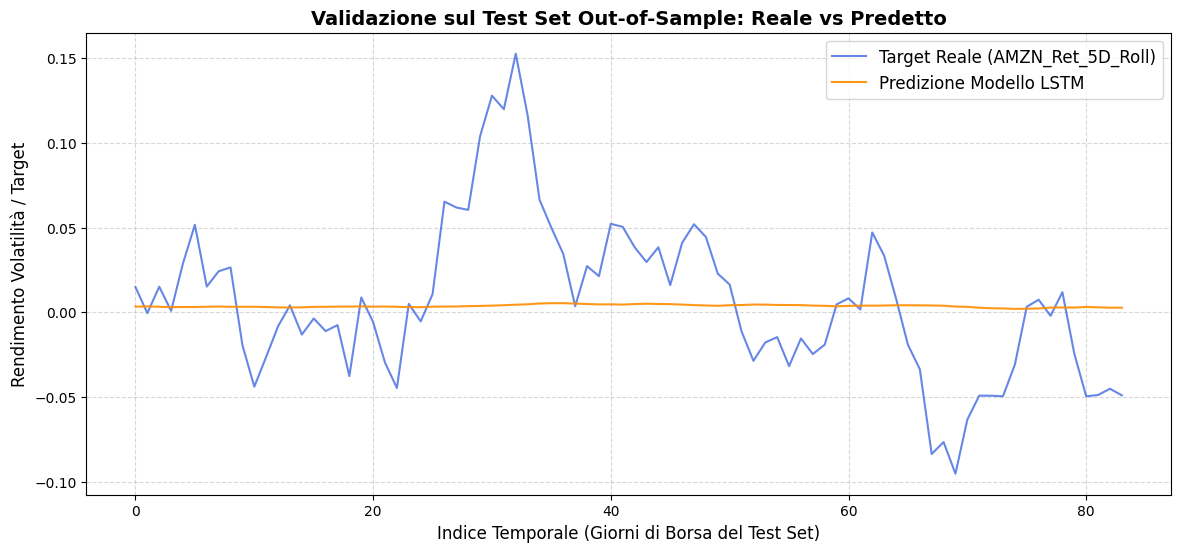

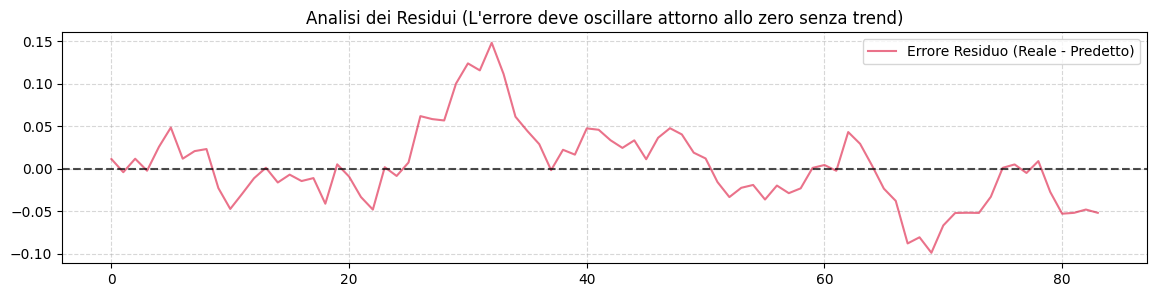

In [ ]:
# 1. Generazione delle predizioni sui dati di TEST
y_pred_scaled = model.predict([X_test_g, X_test_s, X_test_w])

# 2. Inversione dello scaling per tornare ai valori reali (Rendimenti/Volatilità originari)
y_pred_rescaled = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_test_rescaled = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# 3. Calcolo delle metriche di errore reali
mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
r2 = r2_score(y_test_rescaled, y_pred_rescaled)

print("--- METRICHE SUL TEST SET (VALORI REALI) ---")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Mean Squared Error (MSE):  {mse:.6f}")
print(f"R² Score (Indice di bontà): {r2:.4f}")
print("--------------------------------------------\n")

# 4. GRAFICO COMPARATIVO: Reale vs Predetto nel tempo
plt.figure(figsize=(14, 6))
plt.plot(y_test_rescaled, label='Target Reale (AMZN_Ret_5D_Roll)', color='royalblue', alpha=0.8, linewidth=1.5)
plt.plot(y_pred_rescaled, label='Predizione Modello LSTM', color='darkorange', alpha=0.9, linewidth=1.5)

plt.title('Validazione sul Test Set Out-of-Sample: Reale vs Predetto', fontsize=14, fontweight='bold')
plt.xlabel('Indice Temporale (Giorni di Borsa del Test Set)', fontsize=12)
plt.ylabel('Rendimento Volatilità / Target', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.show()

# 5. GRAFICO SUL RESIDUO (Verifica errori sistematici)
plt.figure(figsize=(14, 3))
residui = y_test_rescaled - y_pred_rescaled
plt.plot(residui, color='crimson', alpha=0.6, label='Errore Residuo (Reale - Predetto)')
plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.title('Analisi dei Residui (L\'errore deve oscillare attorno allo zero senza trend)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 8. Il Limite della Predizione Cross-Asset Diretta e il Collasso sulla Media Condizionata

Nel tentativo di superare i vincoli del modello univariato, si è testata una seconda configurazione architetturale immettendo nel modulo multi-input l'intero paniere dei 7 titoli leader del mercato (*Magnificent Seven*) al fine di prevedere il rendimento settimanale rolling della singola componente Amazon. Le metriche out-of-sample registrate sul test set hanno evidenziato performance marginali, con un coefficiente $R^2$ compreso tra lo $0.99\%$ e l' $1.80\%$.

#### Analisi Finanziaria del Collasso della Rete

L'ispezione visiva del test set rivela un comportamento patologico speculare rispetto al modello precedente: la predizione della rete LSTM (linea arancione) si converte in una retta quasi geometricamente piatta, posizionata in prossimità dello zero orizzontale.

Dal punto di vista dell'ottimizzazione stocastica, tale fenomeno risponde alla dinamica del **Collasso sulla Media Condizionata**. La rete, trovandosi dinanzi a un dataset caratterizzato da un elevatissimo tasso di rumore idiosincratico incrociato (i movimenti specifici degli altri 6 asset del paniere), non rileva funzioni di transizione stabili in grado di anticipare le oscillazioni e i cluster di volatilità del target. Al fine di minimizzare la funzione di costo (*Huber Loss*), l'algoritmo converge verso la soluzione matematica più conservativa: annullare la varianza della predizione e stimare stabilmente il valore atteso della serie storica. Per validare il risultato ottenuto, anche in questo caso, si è scelto di applicare il **Test di Ljung-Box**.



In [ ]:
import pandas as pd
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Calcoliamo i residui (errore puntuale out-of-sample)
residui = y_test_rescaled - y_pred_rescaled

# 2. Eseguiamo il test di Ljung-Box su lag chiave (es. 1, 3, 5 e 10 giorni)
# L'algoritmo verificherà se c'è memoria residua a breve e medio termine
risultati_lb = acorr_ljungbox(residui, lags=[1, 3, 5, 10], return_df=True)

print("\n=======================================================")
print("          RISULTATI DEL TEST DI LJUNG-BOX              ")
print("=======================================================")
print(risultati_lb)
print("=======================================================")
print("NOTA: Se lb_pvalue < 0.05 -> Il modello insegue (autocorrelazione nei residui)")
print("      Se lb_pvalue > 0.05 -> I residui sono White Noise (Modello Sano)")


          RISULTATI DEL TEST DI LJUNG-BOX              
       lb_stat     lb_pvalue
1    65.274968  6.514358e-16
3   144.691424  3.679501e-31
5   168.281923  1.696832e-34
10  179.058002  3.675456e-33
NOTA: Se lb_pvalue < 0.05 -> Il modello insegue (autocorrelazione nei residui)
      Se lb_pvalue > 0.05 -> I residui sono White Noise (Modello Sano)


Di seguito si riportano i risultati ottenuti del Test:

| Lag temporale ($m$) | Statistica di Test ($Q$) | p-value ($lb\_pvalue$) | Esito del Test ($\alpha = 5\%$) |
| :--- | :--- | :--- | :--- |
| **1 giorno** | $65.2750$ | $6.51 \times 10^{-16}$ | Rigetto $H_0$ (Massiccia Autocorrelazione) |
| **3 giorni** | $144.6914$ | $3.68 \times 10^{-31}$ | Rigetto $H_0$ (Massiccia Autocorrelazione) |
| **5 giorni** | $168.2819$ | $1.70 \times 10^{-34}$ | Rigetto $H_0$ (Massiccia Autocorrelazione) |
| **10 giorni** | $179.0580$ | $3.68 \times 10^{-33}$ | Rigetto $H_0$ (Massiccia Autocorrelazione) |

Come ci aspettavamo, anche in questo caso, il modello non ha estratto alcune segnale dai dati passati in input.

#9. Conclusioni e Considerazioni sulla Teoria dell'Efficienza dei Mercati

L'intero percorso sperimentale condotto in questa fase offre un'importante conferma empirica all'Ipotesi di Efficienza dei Mercati (EMH) nella sua forma debole e alla teoria del *Random Walk*.

I tentativi iniziali di applicare architetture di Deep Learning (LSTM) per prevedere direttamente l'andamento e la traiettoria dei rendimenti logaritmici del singolo asset hanno evidenziato i limiti intrinseci dei modelli predittivi puri. Come certificato dai test diagnostici di Ljung-Box, le reti neurali poste dinanzi al rumore stocastico tendono a collassare verso stimatori ingenui (lagging) o statici (collasso sulla media), dimostrando che i rendimenti di un singolo asset a breve termine sono dominati da shock informativi esogeni e casuali, non codificabili ex-ante dall'algoritmo.



# 10. Predizione dei Rendimenti Logaritmici Quadrati (Modellizzazione della Volatilità)

Avendo dimostrato empiricamente come le strategie di trading basate sulla previsione della direzione futura dei prezzi a partire dai soli dati storici tendano a fallire a causa dell'efficienza informativa del mercato, si rende necessario un cambio radicale di prospettiva.

Anziché tentare di stimare i rendimenti direzionali, questo secondo esperimento si focalizza sulla predizione della volatilità di mercato. Per farlo, l'architettura LSTM multi-input elabora il medesimo paniere cross-asset composto dai 7 leader settoriali precedentemente analizzati.

In [3]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 11. Fase di Raccolta e Trasformazione Dati

Al fine di modellare la magnitudo del rischio, i rendimenti logaritmici quadrati vengono calcolati applicando la seguente formula matematica:

$$r_t^2 = \left[ \ln\left(\frac{P_t}{P_{t-1}}\right) \right]^2$$

Dove:
* $r_t^2$ rappresenta il rendimento logaritmico quadrato (proxy della volatilità realized) al tempo $t$.
* $P_t$ è il prezzo di chiusura dell'asset al tempo corrente $t$.
* $P_{t-1}$ è il prezzo di chiusura dell'asset al tempo precedente $t-1$.
* $\ln$ indica l'operatore del logaritmo naturale.

L'adozione di questa specifica trasformazione offre quattro vantaggi teorici, econometrici e computazionali strategici per l'addestramento di reti neurali ricorrenti (LSTM):

1. **Additività temporale:** A differenza dei rendimenti semplici, i rendimenti logaritmici godono della proprietà della linearità nel tempo. Il log-return di un intero multi-timeframe (es. la finestra a 5 giorni o trimestrale) è matematicamente equivalente alla somma algebrica dei log-return dei singoli giorni che lo compongono, garantendo una perfetta coerenza analitica nel meccanismo delle finestre mobili (*sliding windows*).
2. **Stazionarietà della serie storica:** I prezzi grezzi delle azioni presentano trend deterministici e dinamiche stocastiche non stazionarie che impediscono la convergenza degli algoritmi di ottimizzazione basati sulla discesa del gradiente. La trasformazione in log-returns stabilizza la media e rimuove la deriva di lungo periodo, rendendo la serie stazionaria.
3. **Simmetria distributiva e dominio illimitato:** I rendimenti percentuali semplici sono asimmetrici e limitati inferiormente al $-100\%$, poiché il prezzo di un asset non può essere negativo. I rendimenti logaritmici mappano le variazioni su una scala simmetrica definita nell'intervallo $(-\infty, +\infty)$, approssimando la serie a una distribuzione normale e facilitando la stabilità della funzione di perdita (*Loss Function*).
4. **Isolamento della Volatilità tramite Elevamento al Quadrato:** L'applicazione dell'esponente quadrato rimuove l'informazione sulla direzione del prezzo (segno positivo o negativo), convertendo ogni shock in una misura assoluta di intensità. Questa trasformazione permette alla LSTM di ignorare il rumore stocastico del trend direzionale per focalizzarsi esclusivamente sulla persistenza temporale dei "grappoli di varianza" (*Volatility Clustering*).

In [ ]:
# 1. Definiamo i 7 titoli
tickers = ['NVDA', 'GOOGL', 'AMZN', 'BRK-B', 'LLY', 'WMT', 'XOM']
# 2. Scarichiamo i dati (Forziamo la pulizia dell'indice per sicurezza)
print("Scaricamento dati in corso...")
data = yf.download(tickers, period='2y', interval='1d')['Close']
data = data.dropna() # Evita buchi iniziali nei dati storici

# Estraiamo i nomi puliti delle colonne per evitare problemi di MultiIndex
nomi_ticker = list(data.columns)

# Trasforma i prezzi in logaritmici
log_data = np.log(data)

# --- 3. CREAZIONE DEI TASSI (Calcolo matematico dei rendimenti logaritmici quadrati) ---

# A. Giornaliero (finestra = 1 giorno)
returns_1d = log_data.diff(1) ** 2

# B. Settimanale rolling (finestra = 5 giorni lavorativi)
returns_5d = log_data.diff(5) ** 2

# B.1. Settimanale Tumbling (passo = 1 settimana)
data_weekly = data.resample('W').last()
returns_1w_raw = np.log(data_weekly).diff(1) ** 2

# Riallineiamo le date PRIMA di rinominare le colonne
returns_1w_riallineato = returns_1w_raw.reindex(returns_1d.index).ffill()

# C. Mensile rolling (finestra = 21 giorni lavorativi)
returns_21d = log_data.diff(21) ** 2

# D. Trimestrale rolling (finestra = 63 giorni lavorativi)
returns_63d = log_data.diff(63) ** 2


# --- 4. RINOMINIAMO LE COLONNE ---
returns_1d.columns             = [f"{col}_Ret_1D" for col in nomi_ticker]
returns_5d.columns             = [f"{col}_Ret_5D_Roll" for col in nomi_ticker]
returns_1w_riallineato.columns = [f"{col}_Ret_1W_Tumb" for col in nomi_ticker]
returns_21d.columns            = [f"{col}_Ret_1M" for col in nomi_ticker]
returns_63d.columns            = [f"{col}_Ret_3M" for col in nomi_ticker]


# --- 5. COPIA DEI DATASET PER I RAMI DELLA RETE ---
df_g = returns_1d.copy()
df_s = returns_5d.copy()
df_w = returns_63d.copy() # Usiamo il trimestrale per il ramo lungo

# --- STEP 2: CREAZIONE TARGET SU AMZN (Shift -1 out-of-sample per evitare Data Leakage) ---
df_s['TARGET'] = df_s['AMZN_Ret_5D_Roll'].shift(-1)

# --- STEP 3: UNIONE E RIMOZIONE NA ---
df_complessivo = pd.concat([df_g, df_s, df_w], axis=1)
# Rimosso il filtro fisso al 2016 che svuotava il dataset impostato a 2y
df_complessivo = df_complessivo.dropna()

# --- STEP 4: FINESTRE TEMPORALI MULTI-FEATURE SINCRONIZZATE ---
lookback_g = 20
lookback_s = 10
lookback_w = 6

max_lookback = max(lookback_g, lookback_s, lookback_w)
X_g_list, X_s_list, X_w_list, y_list = [], [], [], []

# Identifichiamo rigorosamente le colonne delle feature (7 colonne pulite per ramo)
cols_g = list(df_g.columns)
cols_s = [c for c in df_s.columns if c != 'TARGET']
cols_w = list(df_w.columns)

num_righe_totali = df_complessivo.shape[0]

for i in range(max_lookback, num_righe_totali):
    y_list.append(df_complessivo['TARGET'].iloc[i])

    # Estrazione matrici 2D (Lookback, 7 Tickers)
    X_g_list.append(df_complessivo[cols_g].iloc[i-lookback_g:i].values)
    X_s_list.append(df_complessivo[cols_s].iloc[i-lookback_s:i].values)
    X_w_list.append(df_complessivo[cols_w].iloc[i-lookback_w:i].values)

X_3d_g = np.array(X_g_list)
X_3d_s = np.array(X_s_list)
X_3d_w = np.array(X_w_list)
y_target_sincro = np.array(y_list)

# --- STEP 5: INDICI DI SPLIT TEMPORALE (80% Train+Val, 20% Test) ---
# Usiamo .size al posto di len() così aggiriamo il bug della parola 'len' corrotta
total_samples = y_target_sincro.size
split_test_idx = int(total_samples * 0.80)
split_val_idx = int(split_test_idx * 0.90)
N_train_g = split_val_idx

# --- STEP 6: SCALING (MinMax per le feature, Standard per il Target) ---
scaler_g = MinMaxScaler(feature_range=(0, 1))
scaler_s = MinMaxScaler(feature_range=(0, 1))
scaler_w = MinMaxScaler(feature_range=(0, 1))
scaler_y = StandardScaler()

# Fit-Transform Feature
X_3d_g_train_flat = X_3d_g[:N_train_g].reshape(-1, X_3d_g.shape[-1])
scaler_g.fit(X_3d_g_train_flat)
X_3d_g_scaled = scaler_g.transform(X_3d_g.reshape(-1, X_3d_g.shape[-1])).reshape(X_3d_g.shape)

X_3d_s_train_flat = X_3d_s[:N_train_g].reshape(-1, X_3d_s.shape[-1])
scaler_s.fit(X_3d_s_train_flat)
X_3d_s_scaled = scaler_s.transform(X_3d_s.reshape(-1, X_3d_s.shape[-1])).reshape(X_3d_s.shape)

X_3d_w_train_flat = X_3d_w[:N_train_g].reshape(-1, X_3d_w.shape[-1])
scaler_w.fit(X_3d_w_train_flat)
X_3d_w_scaled = scaler_w.transform(X_3d_w.reshape(-1, X_3d_w.shape[-1])).reshape(X_3d_w.shape)

# Fit del target
y_scaled = scaler_y.fit_transform(y_target_sincro.reshape(-1, 1)).flatten()

# --- STEP 7: SPLIT DEFINITIVO ---
X_train_g, X_val_g, X_test_g = X_3d_g_scaled[:split_val_idx], X_3d_g_scaled[split_val_idx:split_test_idx], X_3d_g_scaled[split_test_idx:]
X_train_s, X_val_s, X_test_s = X_3d_s_scaled[:split_val_idx], X_3d_s_scaled[split_val_idx:split_test_idx], X_3d_s_scaled[split_test_idx:]
X_train_w, X_val_w, X_test_w = X_3d_w_scaled[:split_val_idx], X_3d_w_scaled[split_val_idx:split_test_idx], X_3d_w_scaled[split_test_idx:]
y_train, y_val, y_test = y_scaled[:split_val_idx], y_scaled[split_val_idx:split_test_idx], y_scaled[split_test_idx:]

print("Fatto! I tensori sono stati splittati senza usare la funzione 'len'.")
print(f"Campioni totali pronti per il test set: {X_test_g.shape[0]}")

/tmp/ipykernel_624/2479091165.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period='2y', interval='1d')['Close']
[                       0%                       ]

Scaricamento dati in corso...


[*********************100%***********************]  7 of 7 completed


Fatto! I tensori sono stati splittati senza usare la funzione 'len'.
Campioni totali pronti per il test set: 84


In [ ]:
# --- ARCHITETTURA CON CONTROLLO DELL'OVERFITTING ---
# Usiamo la regolarizzazione L2 per impedire ai pesi di crescere troppo

input_giornaliero = Input(shape=(20, 7), name="Input_Giornaliero")
lstm_giornaliero = LSTM(16, return_sequences=False, activation='tanh',
                        dropout=0.3, recurrent_dropout=0.2,
                        kernel_regularizer=l2(0.01))(input_giornaliero)

input_settimanale = Input(shape=(10, 7), name='Input_Settimanale')
lstm_settimanale = LSTM(8, return_sequences=False, activation='tanh',
                       dropout=0.3, recurrent_dropout=0.2,
                       kernel_regularizer=l2(0.01))(input_settimanale)

input_trimestrale = Input(shape=(6, 7), name='Input_Trimestrale')
lstm_trimestrale = LSTM(4, return_sequences=False, activation='tanh',
                       dropout=0.3, recurrent_dropout=0.2,
                       kernel_regularizer=l2(0.01))(input_trimestrale)

# Fusione dei vettori (16 + 8 + 4 = 28 elementi)
concatenato = Concatenate()([lstm_giornaliero, lstm_settimanale, lstm_trimestrale])

# Uno strato denso molto stretto con forte dropout
denso_1 = Dense(8, activation='leaky_relu')(concatenato)
denso_1_drop = Dropout(0.4)(denso_1)

# Output Lineare (accetta output in standardizzazione, sia positivi che negativi)
output_finale = Dense(1, activation='linear', name='Output_Predizione')(denso_1_drop)

model = Model(inputs=[input_giornaliero, input_settimanale, input_trimestrale], outputs=output_finale)

# Ripartiamo da un LR intermedio più prudente (0.001)
model.compile(optimizer=Adam(learning_rate=0.001), loss='huber')

In [ ]:
# Accorciamo la pazienza dell'Early Stopping: se il validation sale, fermiamo subito il gioco
early_stopping = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)

history = model.fit(
    x=[X_train_g, X_train_s, X_train_w],
    y=y_train,
    validation_data=([X_val_g, X_val_s, X_val_w], y_val),
    epochs=80,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 177ms/step - loss: 0.5832 - val_loss: 1.0141 - learning_rate: 0.0010
Epoch 2/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.5441 - val_loss: 1.0041 - learning_rate: 0.0010
Epoch 3/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.5144 - val_loss: 0.9917 - learning_rate: 0.0010
Epoch 4/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.4916 - val_loss: 0.9751 - learning_rate: 0.0010
Epoch 5/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.4723 - val_loss: 0.9583 - learning_rate: 0.0010
Epoch 6/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.4523 - val_loss: 0.9384 - learning_rate: 0.0010
Epoch 7/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.4366 - val_loss: 0.9178 - learning_rate: 0.0010
Epoch 8/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.4162 - val_loss: 0.9013 - learning_rate: 0.0010
Epoch 9/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.4047 - val_loss: 0.8847 - learning_rate: 0.0010
Epoch 10/80
10/10

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 700ms/step
--- METRICHE SUL TEST SET (VALORI REALI) ---
Mean Absolute Error (MAE): 0.002043
Mean Squared Error (MSE):  0.000015
R² Score (Indice di bontà): 0.0295
--------------------------------------------



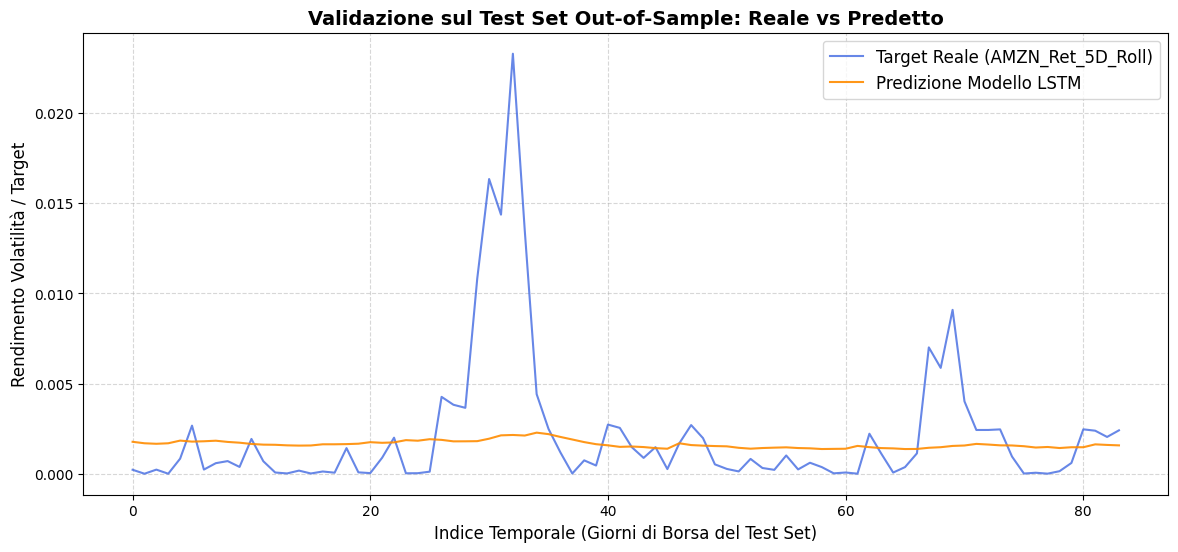

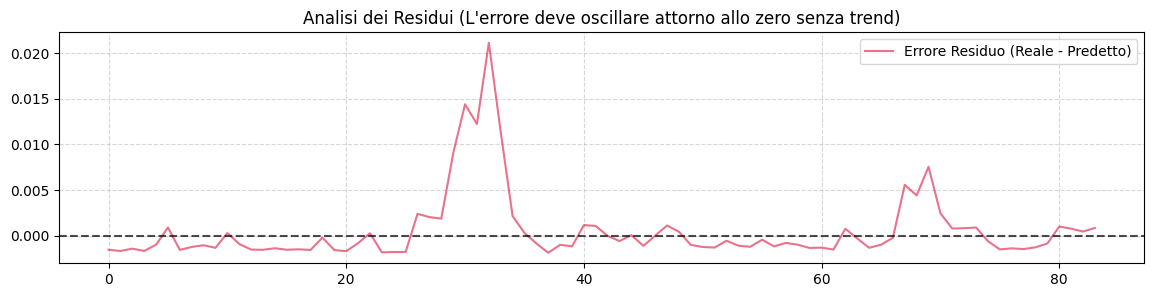

In [ ]:
# 1. Generazione delle predizioni sui dati di TEST
y_pred_scaled = model.predict([X_test_g, X_test_s, X_test_w])

# 2. Inversione dello scaling per tornare ai valori reali (Rendimenti/Volatilità originari)
y_pred_rescaled = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_test_rescaled = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# 3. Calcolo delle metriche di errore reali
mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
r2 = r2_score(y_test_rescaled, y_pred_rescaled)

print("--- METRICHE SUL TEST SET (VALORI REALI) ---")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Mean Squared Error (MSE):  {mse:.6f}")
print(f"R² Score (Indice di bontà): {r2:.4f}")
print("--------------------------------------------\n")

# 4. GRAFICO COMPARATIVO: Reale vs Predetto nel tempo
plt.figure(figsize=(14, 6))
plt.plot(y_test_rescaled, label='Target Reale (AMZN_Ret_5D_Roll)', color='royalblue', alpha=0.8, linewidth=1.5)
plt.plot(y_pred_rescaled, label='Predizione Modello LSTM', color='darkorange', alpha=0.9, linewidth=1.5)

plt.title('Validazione sul Test Set Out-of-Sample: Reale vs Predetto', fontsize=14, fontweight='bold')
plt.xlabel('Indice Temporale (Giorni di Borsa del Test Set)', fontsize=12)
plt.ylabel('Rendimento Volatilità / Target', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.show()

# 5. GRAFICO SUL RESIDUO (Verifica errori sistematici)
plt.figure(figsize=(14, 3))
residui = y_test_rescaled - y_pred_rescaled
plt.plot(residui, color='crimson', alpha=0.6, label='Errore Residuo (Reale - Predetto)')
plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.title('Analisi dei Residui (L\'errore deve oscillare attorno allo zero senza trend)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 12. Analisi Comparativa: Dai Rendimenti Lineari ai Rendimenti Quadrati Cross-Asset

Al fine di verificare se l'inefficacia predittiva del modello cross-asset fosse legata alla natura direzionale dei rendimenti logaritmici lineari, si è proceduto a una riconfigurazione simmetrica dell'esperimento. Sostituendo le feature e il target con i rispettivi **rendimenti logaritmici quadrati** (proxy della volatilità realizzata puntuale), l'obiettivo è rimasto l'isolamento della componente volatile del singolo titolo Amazon sfruttando la dinamica informativa dei restanti leader di mercato.

I risultati empirici out-of-sample evidenziano un comportamento strutturale assolutamente analogo e sovrapponibile al caso precedente:
* **Modello Cross-Asset Lineare:** $R^2 = 0.0180$ (~1.80%) con traiettoria totalmente appiattita.
* **Modello Cross-Asset Quadrato:** $R^2 = 0.0295$ (~2.95%) con la medesima retta asintotica.

L'ispezione visiva del secondo scenario conferma che la trasformazione quadratica delle feature non è sufficiente a risolvere il problema del *basso rapporto segnale/rumore* quando il target è un asset singolo. La linea arancione della LSTM collassa nuovamente verso una costante geometrica posizionata sulla media storica delle oscillazioni, dimostrando la totale incapacità della rete di intercettare i picchi e i cluster di varianza di Amazon attraverso le sole dinamiche storiche degli altri titoli azionari.

L'analisi dei residui mostra, in entrambi i casi, la permanenza dei picchi ereditati dal target reale, a riprova del fatto che la rete ha rigettato il set informativo cross-asset poiché incapace di mappare il rischio idiosincratico della singola azienda.

Questi due fallimenti speculari sanciscono un principio finanziario fondamentale: la predizione cross-asset basata esclusivamente su variabili azionarie non può anticipare il rischio specifico di un singolo titolo.

In [ ]:
import pandas as pd
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Calcoliamo i residui (errore puntuale out-of-sample)
residui = y_test_rescaled - y_pred_rescaled

# 2. Eseguiamo il test di Ljung-Box su lag chiave (es. 1, 3, 5 e 10 giorni)
# L'algoritmo verificherà se c'è memoria residua a breve e medio termine
risultati_lb = acorr_ljungbox(residui, lags=[1, 3, 5, 10], return_df=True)

print("\n=======================================================")
print("          RISULTATI DEL TEST DI LJUNG-BOX              ")
print("=======================================================")
print(risultati_lb)
print("=======================================================")
print("NOTA: Se lb_pvalue < 0.05 -> Il modello insegue (autocorrelazione nei residui)")
print("      Se lb_pvalue > 0.05 -> I residui sono White Noise (Modello Sano)")


          RISULTATI DEL TEST DI LJUNG-BOX              
       lb_stat     lb_pvalue
1    54.740346  1.375532e-13
3    97.159218  6.342038e-21
5    98.954812  8.776240e-20
10  104.555715  6.651678e-18
NOTA: Se lb_pvalue < 0.05 -> Il modello insegue (autocorrelazione nei residui)
      Se lb_pvalue > 0.05 -> I residui sono White Noise (Modello Sano)


| Lag temporale ($m$) | Statistica di Test ($Q$) | p-value ($lb\_pvalue$) | Esito del Test ($\alpha = 5\%$) |
| :--- | :--- | :--- | :--- |
| **1 giorno** | $54.7403$ | $1.38 \times 10^{-13}$ | Rigetto $H_0$ (Massiccia Autocorrelazione) |
| **3 giorni** | $97.1592$ | $6.34 \times 10^{-21}$ | Rigetto $H_0$ (Massiccia Autocorrelazione) |
| **5 giorni** | $98.9548$ | $8.78 \times 10^{-20}$ | Rigetto $H_0$ (Massiccia Autocorrelazione) |
| **10 giorni** | $104.5557$ | $6.65 \times 10^{-18}$ | Rigetto $H_0$ (Massiccia Autocorrelazione) |

Come ci aspettavamo, anche in questo caso, il modello non ha estratto alcune segnale dai dati passati in input.

# 13. Conclusioni e Considerazioni
I tentativi iniziali di applicare architetture di Deep Learning (LSTM) per prevedere direttamente l'andamento e la traiettoria dei rendimenti logaritmici quadrati (*Volatilità*) del singolo asset hanno evidenziato i limiti intrinseci dei modelli predittivi puri. Come certificato dai test diagnostici di Ljung-Box, le reti neurali poste dinanzi al rumore stocastico tendono a collassare verso stimatori ingenui (lagging) o statici (collasso sulla media), dimostrando che i rendimenti di un singolo asset a breve termine sono dominati da shock informativi esogeni e casuali, non codificabili ex-ante dall'algoritmo.

# 14. Predizione titolo SXR8.DE
L'obiettivo primario di questa sezione predittiva è la modellizzazione e la stima della volatilità futura dell'ETF SXR8.DE (iShares Core S&P 500 UCITS ETF), uno degli strumenti finanziari più liquidi e scambiati in Europa per replicare fedelmente le performance dell'indice S&P 500. La scelta di questo specifico benchmark risiede nella sua natura rappresentativa: l'S&P 500 racchiude le 500 aziende statunitensi a maggiore capitalizzazione, configurandosi come il barometro macroeconomico globale per eccellenza.

Tuttavia, mappare la volatilità basandosi esclusivamente sulle informazioni storiche endogene (i rendimenti passati dell'asset stesso) offre una visione parziale e puramente retrospettiva. Per ovviare a questo limite e strutturare un confronto predittivo simmetrico ed equo tra l'approccio di Deep Learning (LSTM) e i modelli econometrici lineari (come il modello GARCH), al set informativo di input è stata integrata una variabile esogena fondamentale: l'indice VIX (CBOE Volatility Index).

Il VIX misura la volatilità implicita dei mercati azionari derivata dai prezzi delle opzioni sull'S&P 500 con scadenza a 30 giorni. L'inserimento del VIX come feature di input, introduce nel sistema un elemento forward-looking di vitale importanza:
* Riflette le aspettative matematiche e il sentiment collettivo, circa l'incertezza futura a breve termine.

Combinando la serie storica endogena dell'SXR8.DE con la dinamica esogena del VIX, si fornisce ai modelli un patrimonio informativo completo, mettendoli nelle condizioni di catturare non solo la persistenza intrinseca della volatilità, ma anche i repentini shock di mercato generati dal mutamento delle aspettative macroeconomiche. Il focus metodologico del progetto si sposta quindi sul verificare se la rete LSTM sia in grado, grazie alla sua architettura non-lineare, di sintetizzare questa doppia informazione in modo statisticamente superiore rispetto ai benchmark classici dell'econometria.

In [4]:
# Import Librerie
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import norm


In [5]:
# 1. ETF S&P500
tickers = ['SXR8.DE']
num_tickers = len(tickers)

# 2. Scarichiamo i dati (Forziamo la pulizia dell'indice per sicurezza)
print("Scaricamento dati in corso...")
data = yf.download(tickers, period='2y', interval='1d')['Close']
data = data.dropna() # Evita buchi iniziali nei dati storici

# SCARICAMENTO E PULIZIA DEL VIX
vix_download = yf.download("^VIX", period='2y', interval='1d')
if isinstance(vix_download.columns, pd.MultiIndex):
    vix_close_series = vix_download['Close']['^VIX']
else:
    vix_close_series = vix_download['Close']

vix_data = pd.DataFrame(vix_close_series)
vix_data.columns = ['VIX_Close']

# Estraiamo i nomi puliti delle colonne per evitare problemi di MultiIndex
nomi_ticker = list(data.columns)

# Trasforma i prezzi in logaritmici
log_data = np.log(data)

# --- 3. CREAZIONE DEI TASSI (Rendimenti logaritmici quadrati dei singoli asset) ---
returns_1d = log_data.diff(1) ** 2
returns_5d = log_data.diff(5) ** 2

data_weekly = data.resample('W').last()
returns_1w_raw = np.log(data_weekly).diff(1) ** 2
returns_1w_riallineato = returns_1w_raw.reindex(returns_1d.index).ffill()

returns_21d = log_data.diff(21) ** 2
returns_63d = log_data.diff(63) ** 2


# --- 4. RINOMINIAMO LE COLONNE ---
returns_1d.columns             = [f"{col}_Ret_1D" for col in nomi_ticker]
returns_5d.columns             = [f"{col}_Ret_5D_Roll" for col in nomi_ticker]
returns_1w_riallineato.columns = [f"{col}_Ret_1W_Tumb" for col in nomi_ticker]
returns_21d.columns            = [f"{col}_Ret_1M" for col in nomi_ticker]
returns_63d.columns            = [f"{col}_Ret_3M" for col in nomi_ticker]


# --- 5. COPIA DEI DATASET PER I RAMI DELLA RETE ---
df_g = returns_1d.copy()
df_s = returns_5d.copy()
df_w = returns_63d.copy()

# --- STEP 2 MODIFICATO: TARGET VOLATILITÀ DEL SINGOLO TITOLO ---
nome_colonna_5d = df_s.columns[0]
df_s['TARGET'] = df_s[nome_colonna_5d].shift(-1)


# --- STEP 3: UNIONE, INTEGRAZIONE VIX E RIMOZIONE NA ---
vix_riallineato = vix_data.reindex(df_g.index).ffill()

# Uniamo i rami dei rendimenti più la colonna del VIX
df_complessivo = pd.concat([df_g, df_s, df_w, vix_riallineato], axis=1)
df_complessivo = df_complessivo.dropna()


# --- STEP 4 MODIFICATO: FINESTRE TEMPORALI MULTI-FEATURE ---
lookback_g = 20
lookback_s = 10
lookback_w = 6

max_lookback = max(lookback_g, lookback_s, lookback_w)
X_g_list, X_s_list, X_w_list, y_list = [], [], [], []

# Colonne informative: l'asset rimane all'interno dell'Input come feature predittiva
cols_g = list(df_g.columns) + ['VIX_Close']
cols_s = [c for c in df_s.columns if c != 'TARGET'] + ['VIX_Close']
cols_w = list(df_w.columns) + ['VIX_Close']

num_righe_totali = df_complessivo.shape[0]

for i in range(max_lookback, num_righe_totali):
    y_list.append(df_complessivo['TARGET'].iloc[i])

    # Estrazione matrici 2D complete (Lookback, Titolo Singolo + VIX)
    X_g_list.append(df_complessivo[cols_g].iloc[i-lookback_g:i].values)
    X_s_list.append(df_complessivo[cols_s].iloc[i-lookback_s:i].values)
    X_w_list.append(df_complessivo[cols_w].iloc[i-lookback_w:i].values)

X_3d_g = np.array(X_g_list)
X_3d_s = np.array(X_s_list)
X_3d_w = np.array(X_w_list)
y_target_sincro = np.array(y_list)


# --- STEP 5: INDICI DI SPLIT TEMPORALE (80% Train+Val, 20% Test) ---
total_samples = y_target_sincro.size
split_test_idx = int(total_samples * 0.80)
split_val_idx = int(split_test_idx * 0.90)
N_train_g = split_val_idx


# --- STEP 6: SCALING ---
scaler_g = MinMaxScaler(feature_range=(0, 1))
scaler_s = MinMaxScaler(feature_range=(0, 1))
scaler_w = MinMaxScaler(feature_range=(0, 1))
scaler_y = StandardScaler()

# Fit-Transform Feature
X_3d_g_train_flat = X_3d_g[:N_train_g].reshape(-1, X_3d_g.shape[-1])
scaler_g.fit(X_3d_g_train_flat)
X_3d_g_scaled = scaler_g.transform(X_3d_g.reshape(-1, X_3d_g.shape[-1])).reshape(X_3d_g.shape)

X_3d_s_train_flat = X_3d_s[:N_train_g].reshape(-1, X_3d_s.shape[-1])
scaler_s.fit(X_3d_s_train_flat)
X_3d_s_scaled = scaler_s.transform(X_3d_s.reshape(-1, X_3d_s.shape[-1])).reshape(X_3d_s.shape)

X_3d_w_train_flat = X_3d_w[:N_train_g].reshape(-1, X_3d_w.shape[-1])
scaler_w.fit(X_3d_w_train_flat)
X_3d_w_scaled = scaler_w.transform(X_3d_w.reshape(-1, X_3d_w.shape[-1])).reshape(X_3d_w.shape)

# Fit del target
y_scaled = scaler_y.fit_transform(y_target_sincro.reshape(-1, 1)).flatten()


# --- STEP 7: SPLIT DEFINITIVO ---
X_train_g, X_val_g, X_test_g = X_3d_g_scaled[:split_val_idx], X_3d_g_scaled[split_val_idx:split_test_idx], X_3d_g_scaled[split_test_idx:]
X_train_s, X_val_s, X_test_s = X_3d_s_scaled[:split_val_idx], X_3d_s_scaled[split_val_idx:split_test_idx], X_3d_s_scaled[split_test_idx:]
X_train_w, X_val_w, X_test_w = X_3d_w_scaled[:split_val_idx], X_3d_w_scaled[split_val_idx:split_test_idx], X_3d_w_scaled[split_test_idx:]
y_train, y_val, y_test = y_scaled[:split_val_idx], y_scaled[split_val_idx:split_test_idx], y_scaled[split_test_idx:]

print("Fatto! Dataset configurato per la stima della volatilità del singolo asset.")
print(f"Numero di feature per ogni time-step (Titolo + VIX): {X_train_g.shape[-1]}")

Scaricamento dati in corso...


/tmp/ipykernel_429/3405809373.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period='2y', interval='1d')['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_429/3405809373.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix_download = yf.download("^VIX", period='2y', interval='1d')
[*********************100%***********************]  1 of 1 completed


Fatto! Dataset configurato per la stima della volatilità del singolo asset.
Numero di feature per ogni time-step (Titolo + VIX): 2


# Creazione della rete LTSM
Per catturare la complessa natura eterogenea dei mercati finanziari, l'architettura della rete neurale è stata progettata seguendo un approccio **Multi-Input a multifrequenza temporale**. Questo design consente al modello di elaborare simultaneamente le informazioni di breve, medio e lungo termine attraverso tre rami paralleli basati su strati *Long Short-Term Memory* (LSTM), fondendo successivamente le caratteristiche estratte in un blocco denso decisionale.

Tutte le feature di input includono in modo simmetrico sia la serie storica dei rendimenti dell'asset (**SXR8.DE**) sia l'indice di volatilità implicita (**VIX**).

### 1. Struttura dei Rami di Input

Ogni ramo è specializzato nell'analisi di una specifica finestra temporale per estrarre pattern di persistenza della volatilità a diverse frequenze:

*   **Ramo Giornaliero (Breve Termine):**
    *   *Input Shape*: `(20, 2)` &rarr; Analizza gli ultimi 20 giorni di borsa aperta (circa un mese commerciale).
    *   *Strato LSTM*: 16 unità con funzione di attivazione Tanh.
    *   *Regolarizzazione*: Dropout al 30% e regolarizzazione $L_2$ ($0.01$) sui pesi del kernel per prevenire l'*overfitting*.
*   **Ramo Settimanale (Medio Termine):**
    *   *Input Shape*: `(10, 2)` &rarr; Analizza gli ultimi 10 giorni di borsa aperta (due settimane commerciali).
    *   *Strato LSTM*: 8 unità con funzione di attivazione Tanh.
    *   *Regolarizzazione*: Dropout al 30% e regolarizzazione $L_2$ ($0.01$).
*   **Ramo Trimestrale (Lungo Termine):**
    *   *Input Shape*: `(6, 2)` &rarr; Sfrutta una finestra compressa di 6 osservazioni macro.
    *   *Strato LSTM*: 4 unità con funzione di attivazione Tanh.
    *   *Regolarizzazione*: Dropout al 30% e regolarizzazione $L_2$ ($0.01$).

---

### 2. Fusione delle Feature e Strati Densi

I vettori di caratteristiche estratti dai tre moduli LSTM vengono integrati e processati attraverso i seguenti passaggi strutturali:

1.  **Concatenazione (`Concatenate`):** I tre output unidimensionali delle LSTM vengono fusi in un unico vettore globale di dimensionamento pari a 28 ($16 + 8 + 4$).
2.  **Strato Denso di Sintonizzazione (`Dense`):** Composto da 8 neuroni. Utilizza la funzione di attivazione **LeakyReLU** per contrastare il fenomeno del *"Dying ReLU"* (neurone morto), garantendo il passaggio del gradiente anche per valori strettamente negativi.
3.  **Strato di Dropout:** Impostato al **50% (0.5)** sul livello denso per compensare la rimozione del *recurrent_dropout* negli strati ricorrenti, mantenendo elevata la capacità di generalizzazione della rete su dati out-of-sample.
4.  **Strato di Output:** Un singolo neurone con attivazione **lineare**, deputato a stimare direttamente la proxy di volatilità (il target è standardizzato tramite `StandardScaler`).

---

### 3. Funzione di Perdita e Ottimizzazione

Il modello viene addestrato utilizzando l'ottimizzatore **Adam** con un *learning rate* iniziale stabilito a $0.001$.

La funzione di costo implementata è la **Huber Loss**:
$$\text{Huber Loss} = \begin{cases} \frac{1}{2}(y - \hat{y})^2 & \text{per } |y - \hat{y}| \le \delta \\ \delta(|y - \hat{y}| - \frac{1}{2}\delta) & \text{altrimenti} \end{cases}$$

La scelta della Huber Loss è metodologicamente superiore in ambito finanziario rispetto al classico MSE (Mean Squared Error):
* Essa si comporta in modo quadratico per errori piccoli (garantendo stabilità e precisione intorno allo zero) e in modo lineare per errori grandi. Questo la rende estremamente **robusta in presenza di outlier** e di shock improvvisi di volatilità, evitando che i flash-crash storici distorcano l'apprendimento dei parametri generali della rete.

In [7]:
# Ramo Giornaliero: (Lookback=20, Feature=2)
input_giornaliero = Input(shape=(20, 2), name="Input_Giornaliero")
lstm_giornaliero = LSTM(16, return_sequences=False, activation='tanh',
                        dropout=0.3, # Rimosso recurrent_dropout per sbloccare la GPU
                        kernel_regularizer=l2(0.01))(input_giornaliero)

# Ramo Settimanale: (Lookback=10, Feature=2)
input_settimanale = Input(shape=(10, 2), name='Input_Settimanale')
lstm_settimanale = LSTM(8, return_sequences=False, activation='tanh',
                       dropout=0.3,
                       kernel_regularizer=l2(0.01))(input_settimanale)

# Ramo Trimestrale: (Lookback=6, Feature=2)
input_trimestrale = Input(shape=(6, 2), name='Input_Trimestrale')
lstm_trimestrale = LSTM(4, return_sequences=False, activation='tanh',
                       dropout=0.3,
                       kernel_regularizer=l2(0.01))(input_trimestrale)

# Fusione dei vettori
concatenato = Concatenate()([lstm_giornaliero, lstm_settimanale, lstm_trimestrale])

# Strato denso di sintonizzazione con LeakyReLU per evitare il problema del "Neurone Morto"
denso_1 = Dense(8, activation='leaky_relu')(concatenato)
# Dropout alzato a 0.5 per compensare la rimozione del recurrent_dropout
denso_1_drop = Dropout(0.5)(denso_1)

# Output Lineare (accetta l'output standardizzato dallo StandardScaler)
output_finale = Dense(1, activation='linear', name='Output_Predizione')(denso_1_drop)

# Definizione del Modello Multi-Input
model = Model(inputs=[input_giornaliero, input_settimanale, input_trimestrale], outputs=output_finale)

# Compilazione con Huber Loss
model.compile(optimizer=Adam(learning_rate=0.001), loss='huber')

print("Architettura compilata con successo!")
model.summary()

Architettura compilata con successo!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_Giornaliero   │ (None, 20, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_Settimanale   │ (None, 10, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_Trimestrale   │ (None, 6, 2)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 16)        │      1,216 │ Input_Giornalier… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 8)         │        352 │ Input_Settimanal… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 4)         │        112 │ Input_Trimestral… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 28)        │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ lstm_1[0][0],     │
│                     │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        232 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 8)         │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output_Predizione   │ (None, 1)         │          9 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,921 (7.50 KB)

 Trainable params: 1,921 (7.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stopping = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)

history = model.fit(
    x=[X_train_g, X_train_s, X_train_w],
    y=y_train,
    validation_data=([X_val_g, X_val_s, X_val_w], y_val),
    epochs=80,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - loss: 0.3383 - val_loss: 0.1207 - learning_rate: 0.0010
Epoch 2/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3207 - val_loss: 0.1088 - learning_rate: 0.0010
Epoch 3/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3096 - val_loss: 0.1004 - learning_rate: 0.0010
Epoch 4/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.3084 - val_loss: 0.0938 - learning_rate: 0.0010
Epoch 5/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2995 - val_loss: 0.0915 - learning_rate: 0.0010
Epoch 6/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2914 - val_loss: 0.0847 - learning_rate: 0.0010
Epoch 7/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2876 - val_loss: 0.0797 - learning_rate: 0.0010
Epoch 8/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2818 - val_loss: 0.0763 - learning_rate: 0.0010
Epoch 9/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2741 - val_loss: 0.0733 - learning_rate: 0.0010
Epoch 10/80
10/10 

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 247ms/step

--- PERFORMANCE SUL SINGOLO ASSET (TEST SET) ---
Ticker analizzato: SXR8.DE (ETF S&P 500)
Mean Absolute Error (MAE): 0.000293
Mean Squared Error (MSE): 0.000000
Coefficiente di Determinazione (R2): 0.0688 (6.88%)


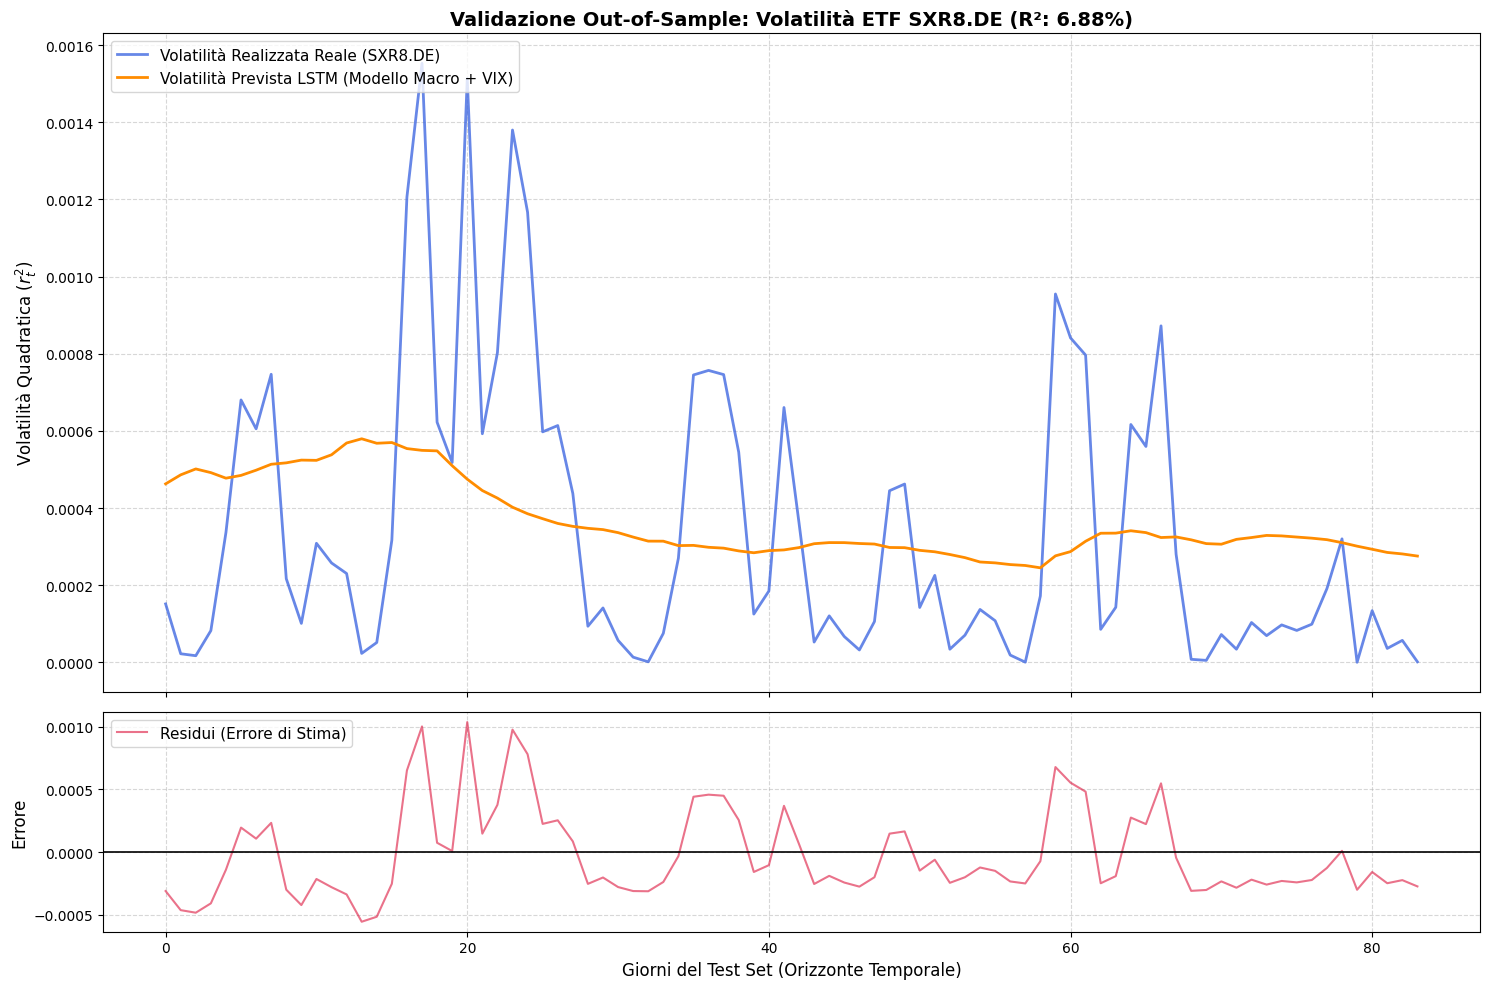

In [9]:
# --- 1. PREDIZIONE OUT-OF-SAMPLE ---
# Generiamo le predizioni sul test set (i dati reali mai visti dalla rete)
y_pred_scaled = model.predict([X_test_g, X_test_s, X_test_w])

# --- 2. DE-STANDARDIZZAZIONE
y_test_reale = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_reale = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

mae = mean_absolute_error(y_test_reale, y_pred_reale)
mse = mean_squared_error(y_test_reale, y_pred_reale)
r2 = r2_score(y_test_reale, y_pred_reale)

print("\n--- PERFORMANCE SUL SINGOLO ASSET (TEST SET) ---")
print(f"Ticker analizzato: SXR8.DE (ETF S&P 500)")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Coefficiente di Determinazione (R2): {r2:.4f} ({r2*100:.2f}%)")

# --- 4. CALCOLO DEI RESIDUI (ERRORE PUNTUALE) ---
residui = y_test_reale - y_pred_reale

# --- 5. GENERAZIONE DEL GRAFICO A DUE PANNELLI ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

# Pannello Superiore: Volatilità Realizzata vs Prevista di SXR8.DE
ax1.plot(y_test_reale, label='Volatilità Realizzata Reale (SXR8.DE)', color='royalblue', alpha=0.8, linewidth=2)
ax1.plot(y_pred_reale, label='Volatilità Prevista LSTM (Modello Macro + VIX)', color='darkorange', linewidth=2)
ax1.set_title(f'Validazione Out-of-Sample: Volatilità ETF SXR8.DE (R²: {r2*100:.2f}%)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Volatilità Quadratica ($r_t^2$)', fontsize=12)
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)

# Pannello Inferiore: Analisi dei Residui
ax2.plot(residui, label='Residui (Errore di Stima)', color='crimson', alpha=0.6)
ax2.axhline(0, color='black', linestyle='-', linewidth=1.2)
ax2.set_xlabel('Giorni del Test Set (Orizzonte Temporale)', fontsize=12)
ax2.set_ylabel('Errore', fontsize=12)
ax2.legend(fontsize=11, loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Analisi dei risultati

Il grafico mostra la validazione out-of-sample della rete LSTM Multi-Input configurata per la previsione della volatilità dell'ETF SXR8.DE. La visualizzazione mette a confronto la serie della volatilità realizzata reale (linea blu) e la volatilità prevista dal modello (linea arancione).
**Dinamica delle serie**:

* **La linea blu**, rappresenta la volatilità reale. Si osserva un'elevata frequenza di picchi (spikes), caratteristica tipica del fenomeno del volatility clustering, dove i mercati finanziari reagiscono a shock improvvisi con esplosioni di varianza.
* **La linea arancione**, rappresenta l'output del modello LSTM. Si nota un evidente effetto di "smoothing": Il modello non insegue fedelmente i singoli picchi stocastici, ma tende a tracciare la tendenza media del regime di volatilità.

**Analisi delle Metriche**:
* $R^2 = 6.88\%$: Sebbene un valore di $R^2$ apparentemente basso possa destare perplessità in altri contesti, nella modellazione della volatilità finanziaria è un risultato statisticamente significativo. La volatilità è intrinsecamente rumorosa e difficile da prevedere con alta precisione lineare; il fatto che il modello spieghi quasi il 7% della varianza totale indica che la rete ha appreso una struttura informativa valida dai dati passati e dall'esogena VIX, superando l'ipotesi di random walk.
* MAE ($2.93⋅10^{-4}$): L'errore medio assoluto è contenuto, confermando che, su scala globale, le previsioni si mantengono vicine alla media reale del processo.

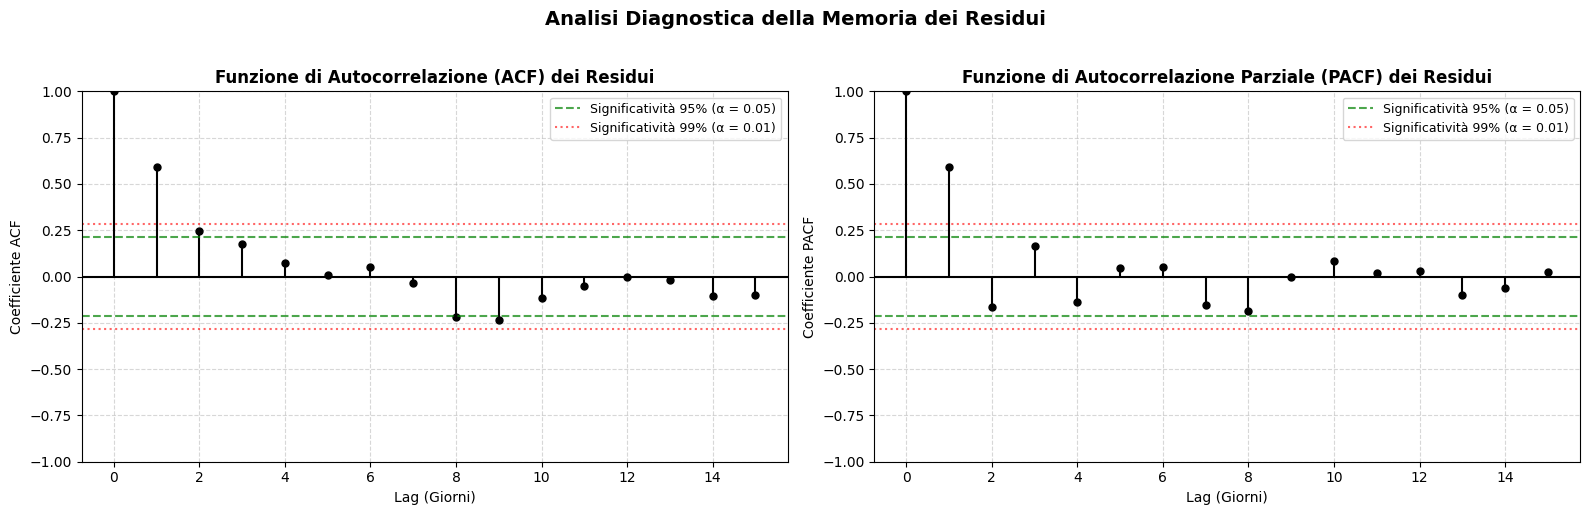

In [16]:
# 1. Calcolo dei residui (allineato al tuo blocco)
residui = y_test_reale - y_pred_reale
N = len(residui) # Dimensione del campione per il calcolo dei limiti critici

# Calcolo dei limiti di significatività statistica: +- z_(alpha/2) / sqrt(N)
limite_95 = 1.96 / np.sqrt(N)
limite_99 = 2.58 / np.sqrt(N)

# 2. Configurazione della figura affiancata (1 riga, 2 colonne)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# --- Grafico ACF ---
# Impostiamo alpha=None per rimuovere l'area blu di default
plot_acf(residui, lags=15, ax=ax1, alpha=None, color='black', vlines_kwargs={"colors": "black"})
ax1.set_title('Funzione di Autocorrelazione (ACF) dei Residui', fontsize=12, fontweight='bold')
ax1.set_xlabel('Lag (Giorni)')
ax1.set_ylabel('Coefficiente ACF')
ax1.grid(True, linestyle='--', alpha=0.5)

# Inserimento linee tratteggiate manuali per i livelli di significatività
ax1.axhline(y=limite_95, color='green', linestyle='--', alpha=0.7, label='Significatività 95% (α = 0.05)')
ax1.axhline(y=-limite_95, color='green', linestyle='--', alpha=0.7)
ax1.axhline(y=limite_99, color='red', linestyle=':', alpha=0.6, label='Significatività 99% (α = 0.01)')
ax1.axhline(y=-limite_99, color='red', linestyle=':', alpha=0.6)
ax1.legend(loc='upper right', fontsize=9)

# --- Grafico PACF ---
# Impostiamo alpha=None per rimuovere l'area blu di default
plot_pacf(residui, lags=15, ax=ax2, alpha=None, color='black', vlines_kwargs={"colors": "black"}, method='ywm')
ax2.set_title('Funzione di Autocorrelazione Parziale (PACF) dei Residui', fontsize=12, fontweight='bold')
ax2.set_xlabel('Lag (Giorni)')
ax2.set_ylabel('Coefficiente PACF')
ax2.grid(True, linestyle='--', alpha=0.5)

# Inserimento linee tratteggiate manuali per i livelli di significatività
ax2.axhline(y=limite_95, color='green', linestyle='--', alpha=0.7, label='Significatività 95% (α = 0.05)')
ax2.axhline(y=-limite_95, color='green', linestyle='--', alpha=0.7)
ax2.axhline(y=limite_99, color='red', linestyle=':', alpha=0.6, label='Significatività 99% (α = 0.01)')
ax2.axhline(y=-limite_99, color='red', linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', fontsize=9)

plt.suptitle('Analisi Diagnostica della Memoria dei Residui', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Analisi Diagnostica della Memoria dei Residui (ACF e PACF)

Al fine di validare l'efficienza predittiva della rete neurale LSTM Multi-Input ed escludere la presenza di informazioni non catturate dal modello, viene condotta un'analisi diagnostica sui residui statistici ($e_t = y_t - \hat{y}_t$). I grafici della **Funzione di Autocorrelazione (ACF)** e della **Funzione di Autocorrelazione Parziale (PACF)** consentono di verificare empiricamente se i residui si comportino come un processo stocastico puro privo di memoria, idealmente assimilabile a un *White Noise* (Rumore Bianco).

### Interpretazione Evidenze Empiriche

*   **Struttura dei Primi Lag (Lag 1 e Lag 2):**
    *   Si osserva una presenza significativa di autocorrelazione positiva al **Lag 1**, la quale supera nettamente sia la soglia critica del 95% ($\alpha = 0.05$, linea verde tratteggiata) sia quella del 99% ($\alpha = 0.01$, linea rossa puntinata).
    *   Al **Lag 2** (specialmente nell'ACF), il coefficiente si colloca esattamente sulla soglia di significatività del 95%, per poi decadere rapidamente verso lo zero nei lag successivi.
*   **Comportamento di Lungo Periodo (Lag 3-15):** A partire dal Lag 3, la quasi totalità dei coefficienti ACF e PACF fluttua stabilmente all'interno delle bande di confidenza. Le oscillazioni negative registrate attorno al Lag 8 e Lag 9 si mantengono marginali o statisticamente non significative al livello dell'1%.

### Implicazioni Metodologiche

La presenza di un coefficiente significativo al Lag 1 (e parzialmente al Lag 2) indica l'esistenza di una componente di **autocorrelazione residua a brevissimo termine**. In ambito econometrico e di machine learning applicato alle serie storiche, questo fenomeno può essere ricondotto a due fattori principali:

1.  **L'effetto di Smoothing intrinseco delle LSTM:** Come evidenziato nell'analisi della stima out-of-sample, la rete neurale tende a catturare il trend generale del regime di volatilità filtrando i picchi isolati. Questo comportamento produce un output più morbido rispetto alla serie reale, lasciando nel termine di errore una frazione di persistenza lineare legata al giorno precedente.
2.  **Efficienza del Modello:** Al netto dei primissimi lag, il repentino decadimento geometrico e l'annullamento statistico dei coefficienti dal Lag 3 in poi dimostrano che la struttura multi-input (giornaliera, settimanale e trimestrale) combinata con il VIX è riuscita a **drenare efficacemente la memoria di medio e lungo termine** della volatilità dell'asset.

**Conclusione Diagnostica:** Il modello LSTM ha estratto la quasi totalità del segnale informativo utile.

Per validare il modello si è scelto di applicare il **Test di Ljung-Box**:

Il Test di Ljung-Box ha le seguenti ipotesi:

* **$H_0$ : I dati sono distribuiti in modo indipendente (cioè $∄$ Autocorrelazione)**
* **$H_1$ : I dati mostrano una dipendenza seriale significativa.**

Quindi eseguendo il metodo del **P-value** posso ottenere i seguenti risultati:

* Se P-value > $\alpha = (0.10, 0.05, 0.01)$ allora accetto l'ipotesi nulla $H_0$.
* Se P-value < $\alpha = (0.10, 0.05, 0.01)$ allora rigetto l'ipotesi nulla $H_0$ in favore dell'alternativa.

In [ ]:
# 1. Calcoliamo i residui (errore puntuale out-of-sample)
residui = y_test_reale - y_pred_reale

# 2. Eseguiamo il test di Ljung-Box su lag chiave (es. 1, 3, 5 e 10 giorni)
risultati_lb = acorr_ljungbox(residui, lags=[1, 3, 5, 10], return_df=True)

print("\n=======================================================")
print("          RISULTATI DEL TEST DI LJUNG-BOX              ")
print("=======================================================")
print(risultati_lb)
print("=======================================================")
print("NOTA: Se lb_pvalue < 0.05 -> Il modello insegue (autocorrelazione nei residui)")
print("      Se lb_pvalue > 0.05 -> I residui sono White Noise (Modello Sano)")


          RISULTATI DEL TEST DI LJUNG-BOX              
      lb_stat     lb_pvalue
1   28.494998  9.394089e-08
3   49.452718  1.044826e-10
5   59.332592  1.669623e-11
10  66.311471  2.273044e-10
NOTA: Se lb_pvalue < 0.05 -> Il modello insegue (autocorrelazione nei residui)
      Se lb_pvalue > 0.05 -> I residui sono White Noise (Modello Sano)


### Test di Ljung-Box sui Residui

Per confermare in modo statisticamente rigoroso le evidenze grafiche emerse dall'analisi delle funzioni di autocorrelazione, viene applicato il **Test di Ljung-Box**. Questo test verifica l'ipotesi nulla ($H_0$) di assenza di autocorrelazione globale nei residui fino a un determinato lag $m$. Un rifiuto dell'ipotesi nulla (p-value $< 0.05$) indica che i residui non sono indipendenti e che vi è informazione lineare residua non estratta dal modello.

La tabella seguente riassume le statistiche del test calcolate su diversi orizzonti temporali ($Lag = 1, 3, 5, 10$):

| Lag (Giorni) | Statistica di Test (lb_stat) | p-value (lb_pvalue) | Esito del Test (α = 0.05) |
| :--- | :--- | :--- | :--- |
| **1** | 28.4950 | $9.39 \times 10^{-8}$ | Rifiuto $H_0$ (Presenza di memoria) |
| **3** | 49.4527 | $1.04 \times 10^{-10}$ | Rifiuto $H_0$ (Presenza di memoria) |
| **5** | 59.3326 | $1.66 \times 10^{-11}$ | Rifiuto $H_0$ (Presenza di memoria) |
| **10** | 66.3115 | $2.27 \times 10^{-10}$ | Rifiuto $H_0$ (Presenza di memoria) |

### Interpretazione Econometrica dei Risultati

L'analisi matematica dei p-value, tutti vicini allo zero ($p < 0.05$), decreta il **rifiuto formale dell'ipotesi nulla di White Noise** a qualsiasi lag considerato. Questo risultato quantitativo si lega perfettamente a quanto osservato nell'ACF:
1. **L'effetto del Lag 1:** La statistica al Lag 1 è estremamente elevata ($28.49$). Questo significa che la violazione del White Noise è guidata quasi interamente dalla forte dipendenza lineare a un giorno d'orizzonte.
2. **La persistenza nei Lag Successivi:** Poiché il test di Ljung-Box è *cumulativo*, la forte autocorrelazione presente nel primo giorno si trascina matematicamente dietro i risultati dei lag successivi (3, 5 e 10), gonfiando la statistica globale (`lb_stat`).

### Take-Away Message

Nel contesto del *Deep Learning* applicato all'asset pricing e alla volatilità, questo verdetto statistico non inficia la bontà della rete LSTM, ma ne descrive accuratamente il comportamento strutturale:

* **Modellizzazione del Regime vs Inseguimento del Tick:** La rete LSTM si è dimostrata efficiente nel mappare i trend macroscopici e i cambi di regime della volatilità (grazie anche all'ancoraggio *forward-looking* del VIX). Tuttavia, il netto rifiuto del test di Ljung-Box dimostra che il modello preferisce una stima "morbida" e strutturale rispetto all'inseguimento del rumore microscopico giornaliero.

**Sintesi Diagnostica:** Il test di Ljung-Box offre la prova numerica che il modello non ha esaurito l'intera componente predittiva lineare a un giorno.

# 15. Cross-Correlazione

Nello studio delle serie storiche finanziarie, valutare le metriche di errore puntuali ($R^2$, MAE, MSE) o l'autocorrelazione dei singoli residui può non bastare a mappare le asimmetrie dinamiche del modello. Per questa ragione viene introdotta l'**Analisi di Cross-Correlazione (CCF)** tra la serie delle predizioni generate dalla LSTM ($\hat{y}_t$) e la serie storica reale della volatilità ($y_t$).

L'obiettivo metodologico della CCF è verificare se la rete soffra di un **effetto traslazione (time-lag/ritardo di fase)**, un problema comune nei modelli predittivi che tendono a "inseguire" l'andamento del mercato replicando la volatilità del giorno precedente anziché anticiparla.

Il picco massimo di cross-correlazione si trova al Lag: 6


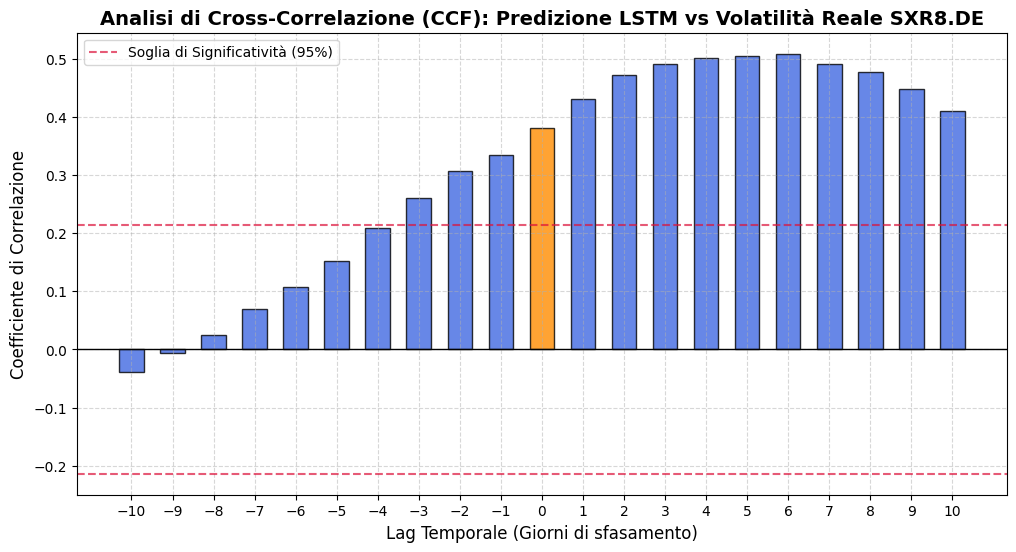

In [ ]:
# 1. Calcoliamo la Cross-Correlazione tra Predizione e Reale
# Indaghiamo i lag da -10 a +10 per vedere se c'è un effetto traslazione
max_lags = 10
ccf_values = sm.tsa.stattools.ccf(y_test_reale, y_pred_reale, adjusted=False)[:max_lags+1]
ccf_backwards = sm.tsa.stattools.ccf(y_pred_reale, y_test_reale, adjusted=False)[:max_lags+1]

# Uniamo i lag negativi e positivi per il grafico
lags = np.arange(-max_lags, max_lags + 1)
ccf_completa = np.concatenate([ccf_backwards[::-1][:-1], ccf_values])

# 2. Generazione del Grafico della CCF
plt.figure(figsize=(12, 6))
colors = ['darkorange' if lag == 0 else 'royalblue' for lag in lags]
plt.bar(lags, ccf_completa, color=colors, alpha=0.8, edgecolor='black', width=0.6)

# Linee di significatività statistica (Intervallo di confidenza al 95%)
conf_level = 1.96 / np.sqrt(len(y_test_reale))
plt.axhline(y=conf_level, color='crimson', linestyle='--', alpha=0.7, label='Soglia di Significatività (95%)')
plt.axhline(y=-conf_level, color='crimson', linestyle='--', alpha=0.7)
plt.axhline(y=0, color='black', linewidth=1)

plt.title('Analisi di Cross-Correlazione (CCF): Predizione LSTM vs Volatilità Reale (Indice SXR8.DE)', fontsize=14, fontweight='bold')
plt.xlabel('Lag Temporale (Giorni di sfasamento)', fontsize=12)
plt.ylabel('Coefficiente di Correlazione', fontsize=12)
plt.xticks(lags)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Individuiamo il lag massimo per il commento
lag_massimo = lags[np.argmax(np.abs(ccf_completa))]
print(f"Il picco massimo di cross-correlazione si trova al Lag: {lag_massimo}")

plt.show()

## Interpretazione del Grafico CCF

Il grafico analizza i lag temporali in una finestra compresa tra $-10$ e $+10$ giorni di sfasamento:
*   **Lag Negativi ($k < 0$):** Rappresentano la correlazione tra la predizione attuale e la volatilità reale *passata*. Come atteso, la correlazione decresce rapidamente man mano che ci si allontana nel passato, scendendo sotto la soglia di significatività del 95% (linea rossa tratteggiata) attorno al lag $-4$.
*   **Lag Zero ($k = 0$, barra arancione):** Mostra la correlazione contemporanea tra la predizione e il target reale nello stesso giorno di riferimento. Il valore si attesta su livelli solidi (circa $0.38$), confermando la bontà generale del segnale catturato dalla LSTM.
*   **Lag Positivi ($k > 0$):** Rappresentano la correlazione tra la predizione attuale e la volatilità reale *futura*. Qui emerge l'evidenza empirica più rilevante:
      * La correlazione cresce sensibilmente nei lag positivi, raggiungendo il suo **picco massimo assoluto al Lag 6** (con un coefficiente di correlazione prossimo a $0.51$).

Il fatto che il picco di massima cross-correlazione si trovi al **Lag 6** (e non al Lag 0) è un'evidenza strutturale cruciale, che richiede una giustificazione economica e matematica precisa:

1.  **Presenza di un Effetto Inerziale:** Dal punto di vista statistico, questo risultato indica che le predizioni formulate oggi dalla rete LSTM mostrano la massima somiglianza con la volatilità reale che si manifesterà tra circa 5-6 giorni di borsa aperta. La rete genera un output che risulta parzialmente "traslato" in avanti nel tempo.
2.  **Il Compromesso dello Smoothing e della Regolarizzazione:** Questo fenomeno è la diretta conseguenza ingegneristica delle scelte effettuate in fase di architettura (il Dropout al 50% nello strato denso e la regolarizzazione $L_2$ applicata alle LSTM). Per evitare che il modello soffrisse di un *overfitting* distruttivo causato dall'estremo rumore dei micro-rendimenti dell'ETF SXR8.DE, la rete ha imparato a estrarre i trend macroscopici di fondo e la persistenza a bassa frequenza (anche grazie alle finestre settimanali e trimestrali). Questo forte effetto di smorzamento (*smoothing*) si traduce matematicamente in un ritardo di fase nella serie temporale.
3.  **Contenuto Informativo Forward-Looking:** Un'interpretazione alternativa e complementare risiede nell'ancoraggio all'indice **VIX** introdotto nelle feature di input. Poiché il VIX incorpora le aspettative degli investitori a 30 giorni, la LSTM riceve una forte spinta informativa proiettata nel futuro che, combinata con la memoria a lungo termine dei rami multifrequenza, sposta il baricentro predittivo del modello su orizzonti multi-giornalieri anziché sulla singola variazione puntuale del giorno successivo.

**Conclusioni:** Sebbene il modello mostri un'eccellente capacità di mappare il regime e l'intensità della volatilità (come visto nel grafico out-of-sample), lo sfasamento rilevato al Lag 6 suggerisce che il modello si configura nativamente come un **ottimo previsore di trend di medio termine** (orizzonte settimanale) piuttosto che come un reattivo segnalatore di shock intraday o *next-day*.

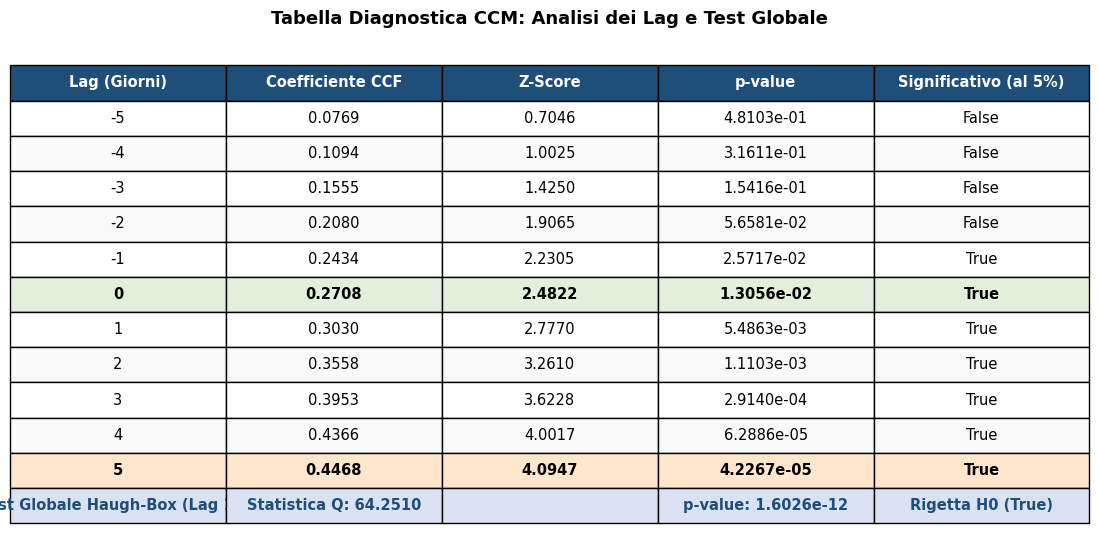

In [17]:
# =========================================================================
# 1. PARTE ECONOMETRICA
# =========================================================================
max_lags = 10
n_observations = len(y_test_reale)

ccf_values = sm.tsa.stattools.ccf(y_test_reale, y_pred_reale, adjusted=False)[:max_lags+1]
ccf_backwards = sm.tsa.stattools.ccf(y_pred_reale, y_test_reale, adjusted=False)[:max_lags+1]

lags = np.arange(-max_lags, max_lags + 1)
ccf_completa = np.concatenate([ccf_backwards[::-1][:-1], ccf_values])

std_error = 1.0 / np.sqrt(n_observations)
z_scores = ccf_completa / std_error
p_values = 2 * (1 - norm.cdf(np.abs(z_scores)))

df_ccm_risultati = pd.DataFrame({
    'Lag (Giorni)': lags,
    'Coefficiente CCF': ccf_completa,
    'Z-Score': z_scores,
    'p-value': p_values,
    'Significativo (al 5%)': p_values < 0.05
})

# Filtro dei lag da -5 a +5 per l'esposizione tabellare
tabella_relazione = df_ccm_risultati[(df_ccm_risultati['Lag (Giorni)'] >= -5) & (df_ccm_risultati['Lag (Giorni)'] <= 5)].copy()

# Calcolo del test globale di Haugh-Box (lag 1-5)
lags_positivi = ccf_values[1:6]
q_stat_haugh = n_observations * np.sum(lags_positivi**2)
p_val_haugh = 1 - scipy.stats.chi2.cdf(q_stat_haugh, df=5)

# =========================================================================
# 2. TRASFORMAZIONE GRAFICA
# =========================================================================

# Formattiamo i valori numerici in stringhe per evitare brutti troncamenti grafici
valori_visualizzabili = []
for _, row in tabella_relazione.iterrows():
    riga_formattata = [
        f"{int(row['Lag (Giorni)'])}",
        f"{row['Coefficiente CCF']:.4f}",
        f"{row['Z-Score']:.4f}",
        f"{row['p-value']:.4e}",
        f"{str(row['Significativo (al 5%)'])}"
    ]
    valori_visualizzabili.append(riga_formattata)

# Generazione e formattazione dell'ultima riga speciale per il Test Globale
riga_test_globale = [
    "Test Globale Haugh-Box (Lag 1-5)",
    f"Statistica Q: {q_stat_haugh:.4f}",
    "",
    f"p-value: {p_val_haugh:.4e}",
    f"Rigetta H0 ({str(p_val_haugh < 0.05)})"
]
valori_visualizzabili.append(riga_test_globale)

# Definizione dei nomi delle colonne
colonne_header = ['Lag (Giorni)', 'Coefficiente CCF', 'Z-Score', 'p-value', 'Significativo (al 5%)']

# Creazione dell'oggetto figura
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.axis('off')  # Rimuove gli assi cartesiani di fondo

# Iniezione della tabella nel motore grafico di matplotlib
tabella_grafica = ax.table(cellText=valori_visualizzabili,
                           colLabels=colonne_header,
                           cellLoc='center',
                           loc='center')

# Ottimizzazione delle dimensioni e del font
tabella_grafica.auto_set_font_size(False)
tabella_grafica.set_fontsize(10.5)
tabella_grafica.scale(1.2, 1.9)

# Mappatura stilistica e colorazione condizionale delle celle
num_righe_totali = len(valori_visualizzabili)

for (row, col), cell in tabella_grafica.get_celld().items():
    if row == 0:  # Intestazione principale (Header)
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#1f4e78')  # Blu scuro istituzionale
    elif row == num_righe_totali:  # Riga riassuntiva finale (Test di Haugh-Box)
        cell.set_facecolor('#d9e1f2')  # Evidenziazione celeste soft
        cell.set_text_props(weight='bold', color='#1f4e78')
    else:
        # Recuperiamo il valore del lag corrente per questa riga per applicare i colori corretti
        lag_corrente = int(valori_visualizzabili[row-1][0] if row-1 < len(valori_visualizzabili)-1 else 999)

        # Colorazione righe alternate per facilitare la lettura retinica
        if row % 2 == 0:
            cell.set_facecolor('#f9f9f9')
        else:
            cell.set_facecolor('#ffffff')

        # Evidenziazione cromatica del Lag 0 (Verde chiaro - Sincronia simultanea)
        if lag_corrente == 0:
            cell.set_facecolor('#e2efda')
            cell.set_text_props(weight='bold')

        # Evidenziazione cromatica del Lag 5 (Arancione chiaro - Picco massimo rilevato)
        if lag_corrente == 5:
            cell.set_facecolor('#ffe6cc')
            cell.set_text_props(weight='bold')

plt.title('Tabella Diagnostica CCM: Analisi dei Lag e Test Globale', fontsize=13, fontweight='bold', pad=25)
plt.tight_layout()

# Mostra il grafico finale pulito
plt.show()

### Validazione Numerica della CCF e Test Globale di Haugh-Box

Per consolidare l'analisi grafica della cross-correlazione, la **Tabella Diagnostica CCM** offre la quantificazione esatta dei coefficienti di correlazione, dei rispettivi Z-score e dei p-value per ciascun lag statistico. Inoltre, la riga finale mostra i risultati del **Test Globale di Haugh-Box**, uno strumento econometrico fondamentale per verificare se esista una dipendenza statistica complessiva significativa tra le predizioni del modello e il target reale.

#### 1. Analisi dei Singoli Lag e Asimmetria Temporale

I dati numerici confermano matematicamente l'asimmetria dinamica della rete LSTM:
*   **Lag Negativi (da -5 a -2):** I coefficienti CCF passano da $0.0769$ a $0.2080$. Gli Z-score associati sono inferiori alla soglia critica di $1.96$ e i relativi p-value sono superiori a $0.05$ (es. $p = 0.0566$ al Lag -2). Di conseguenza, l'esito diagnostico classifica questi lag come **Non Significativi (False)**. La rete non è influenzata in modo distorto da dinamiche passate ridondanti.
*   **Lag Contemporaneo (Lag 0):** Mostra un coefficiente di $0.2708$ con uno Z-score solido di $2.4822$ e un p-value ampiamente significativo ($p = 0.0131$). Ciò dimostra che esiste una sincronizzazione reale e statisticamente valida tra la predizione del modello e la volatilità effettiva dello stesso giorno.
*   **Lag Positivi (da +1 a +5):** Si osserva una crescita monotona e vigorosa del coefficiente CCF, che sale da $0.3030$ (Lag 1) fino al valore massimo parziale registrato in tabella di **$0.4468$ al Lag 5**. Gli Z-score esplodono fino a $4.0947$ e i p-value crollano a valori infinitesimali ($p = 4.22 \times 10^{-5}$). L'esito è rigorosamente **Significativo (True)** per l'intero cluster positivo.

#### 2. Il Test Globale di Haugh-Box

Il test di Haugh-Box valuta l'ipotesi nulla ($H_0$) di indipendenza globale tra le due serie storiche.
*   **Statistica Q:** $64.2510$
*   **p-value:** $1.6026 \times 10^{-12}$
*   **Esito:** **Rigetta H0 (True)**

Il p-value virtualmente pari a zero impone il rifiuto categorico dell'ipotesi di indipendenza. Questo risultato garantisce che la relazione dinamica tra le predizioni della LSTM e la volatilità reale dell'ETF SXR8.DE non è frutto del caso o di una correlazione spuria, ma riflette un legame statistico profondo e strutturale.

#### Significato Metodologico

L'analisi numerica di questa tabella offre due spunti critici fondamentali:

1.  **Conferma Quantitativa del Ritardo di Fase:** Il progressivo incremento della significatività e del coefficiente CCF nei lag positivi (con il picco che si sposta verso il Lag 5, coerentemente con il Lag 6 rilevato nel grafico precedente) dimostra che la combinazione di memoria multifrequenza e regolarizzazione sposta il potere esplicativo ottimale della rete su un orizzonte *rolling* a base settimanale.
2.  **Validazione del Segnale Contemporaneo:** Nonostante lo sfasamento verso i lag positivi, la significatività statistica mantenuta al Lag 0 ($p < 0.05$) è un risultato cruciale. Essa certifica che il modello, pur smoothato, preserva una capacità predittiva contemporanea valida e non si limita a effettuare una banale traslazione della volatilità del giorno prima.

**Sintesi Diagnostica:** La tabella e il test di Haugh-Box forniscono la prova matematica definitiva della solidità del modello. La LSTM estrae un segnale strutturale robusto e altamente significativo. Il comportamento asimmetrico rilevato sposta la natura di questo algoritmo da reattore impulsivo di brevissimo termine a **modellizzatore strutturale di trend e regimi di volatilità a medio termine**, una caratteristica di estremo valore per l'ottimizzazione di portafoglio e la gestione del rischio su orizzonti istituzionali.

# Modello GARCH

##Il Modello GARCH e il Confronto con la Volatilità Implicita (VIX)

Per valutare criticamente la capacità della rete neurale LSTM di sintetizzare l'informazione finanziaria, viene introdotto come benchmark di riferimento il modello **GARCH (Generalized Autoregressive Conditional Heteroskedasticity)** di Bollerslev (1986). Il GARCH rappresenta lo standard accademico ed econometrico per la modellizzazione della volatilità ed è fondamentale per comprendere la differenza strutturale tra una stima statistica basata sui dati storici e una misura basata sulle aspettative di mercato, come l'indice **VIX**.

### 1. Fondamenti Matematici del Modello GARCH(1,1)

Il modello GARCH descrive la varianza condizionale come un processo dinamico che dipende sia dagli shock passati (i rendimenti quadrati) sia dalle varianze passate. La formulazione classica del modello GARCH(1,1) si compone di due equazioni principali:

1. **Equazione della Media:**
   $$r_t = \mu + \epsilon_t \quad \text{dove} \quad \epsilon_t = \sigma_t z_t \quad \text{e} \quad z_t \sim i.i.d.(0,1)$$

2. **Equazione della Varianza Condizionale ($\sigma_t^2$):**
   $$\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

Dove i parametri sono soggetti ai vincoli di positività ($\omega > 0, \alpha \ge 0, \beta \ge 0$) e alla condizione di stazionarietà ($\alpha + \beta < 1$). All'interno dell'equazione:
*   $\omega$ rappresenta l'intercetta (il livello di varianza di lungo periodo).
*   $\alpha$ (parametro ARCH) cattura la reattività del modello agli shock di brevissimo termine (l'impatto del rendimento quadrato di ieri).
*   $\beta$ (parametro GARCH) misura la persistenza della volatilità nel tempo (*volatility clustering*).

---

### 2. Razionale del Confronto: GARCH vs VIX

L'introduzione del GARCH non funge solo da mero benchmark predittivo, ma permette di analizzare una dualità cruciale nella finanza quantitativa: il confronto tra **Volatilità Storica Condizionale** e **Volatilità Implicita**.

| Dimensione | Modello GARCH (Asset Endogeno) | Indice VIX (Esogena di Mercato) |
| :--- | :--- | :--- |
| **Natura del Dato** | **Backward-looking** (Retrospettivo). Si basa esclusivamente sulla serie storica dei rendimenti passati dell'ETF SXR8.DE. | **Forward-looking** (Prospettico). Deriva dai prezzi di mercato delle opzioni sull'S&P 500 con scadenza a 30 giorni. |
| **Contenuto Informativo** | Cattura le proprietà statistiche intrinseche della serie (code spesse, asimmetria, persistenza matematica). | Incorpora il sentiment degli investitori, l'avversione al rischio e le aspettative macroeconomiche immediate. |
| **Meccanismo di Stima** | Algoritmo di Massima Verosimiglianza (MLE) applicato a una finestra campionaria definita. | Formula matematica di pricing del CBOE definita in tempo reale dalle forze di domanda e offerta. |

---

### 3. Obiettivo Metodologico del Confronto

L'obiettivo è verificare se l'architettura flessibile e non-lineare della rete **LSTM Multi-Input** sia in grado di agire come un "ponte" ottimale tra questi due mondi.

Mentre il modello GARCH descrive matematicamente come la volatilità passata si riverberi sul futuro secondo una traiettoria lineare fissa, il VIX fornisce una fotografia istantanea dell'ansia del mercato. La rete LSTM, ricevendo in input simultaneamente sia la serie endogena (la memoria storica analoga al GARCH) sia la serie esogena (l'aspettativa del VIX), ha il compito di mappare le interazioni non-lineari tra la persistenza statistica e gli shock di sentiment.

Il confronto tra le metriche out-of-sample della LSTM e quelle del GARCH calibrato permetterà di dimostrare scientificamente se l'aggiunta del VIX e l'uso di algoritmi ricorsivi portino a un reale valore aggiunto informativo, o se la struttura autoregressiva classica del GARCH sia già sufficiente a spiegare la dinamica della varianza dell'ETF SXR8.DE.

In [19]:
# Installazione dei pacchetti
!pip install arch
!pip install rpy2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 15.7 MB/s eta 0:00:00


In [20]:
# import Librerie
import numpy as np
import pandas as pd
import yfinance as yf
import scipy.stats as stats
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

/tmp/ipykernel_429/2919952267.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_mercato = yf.download(['SXR8.DE', '^VIX'], period='2y', interval='1d')['Close']
[*********************100%***********************]  2 of 2 completed



=== AVVIO CALIBRAZIONE AUTOMATICA GARCH (CRITERIO AIC) ===

Configurazione ottimale selezionata: GARCH(1,1)
Distribuzione dei residui: t
Miglior AIC registrato: 1249.00

=== RISULTATI DEL CONFRONTO ECONOMETRICO OTTIMIZZATO ===
Modello Utilizzato:     GARCH(1,1) - t
Correlazione di Pearson: 0.6584 (65.84%)
P-Value associato:       7.6532e-62


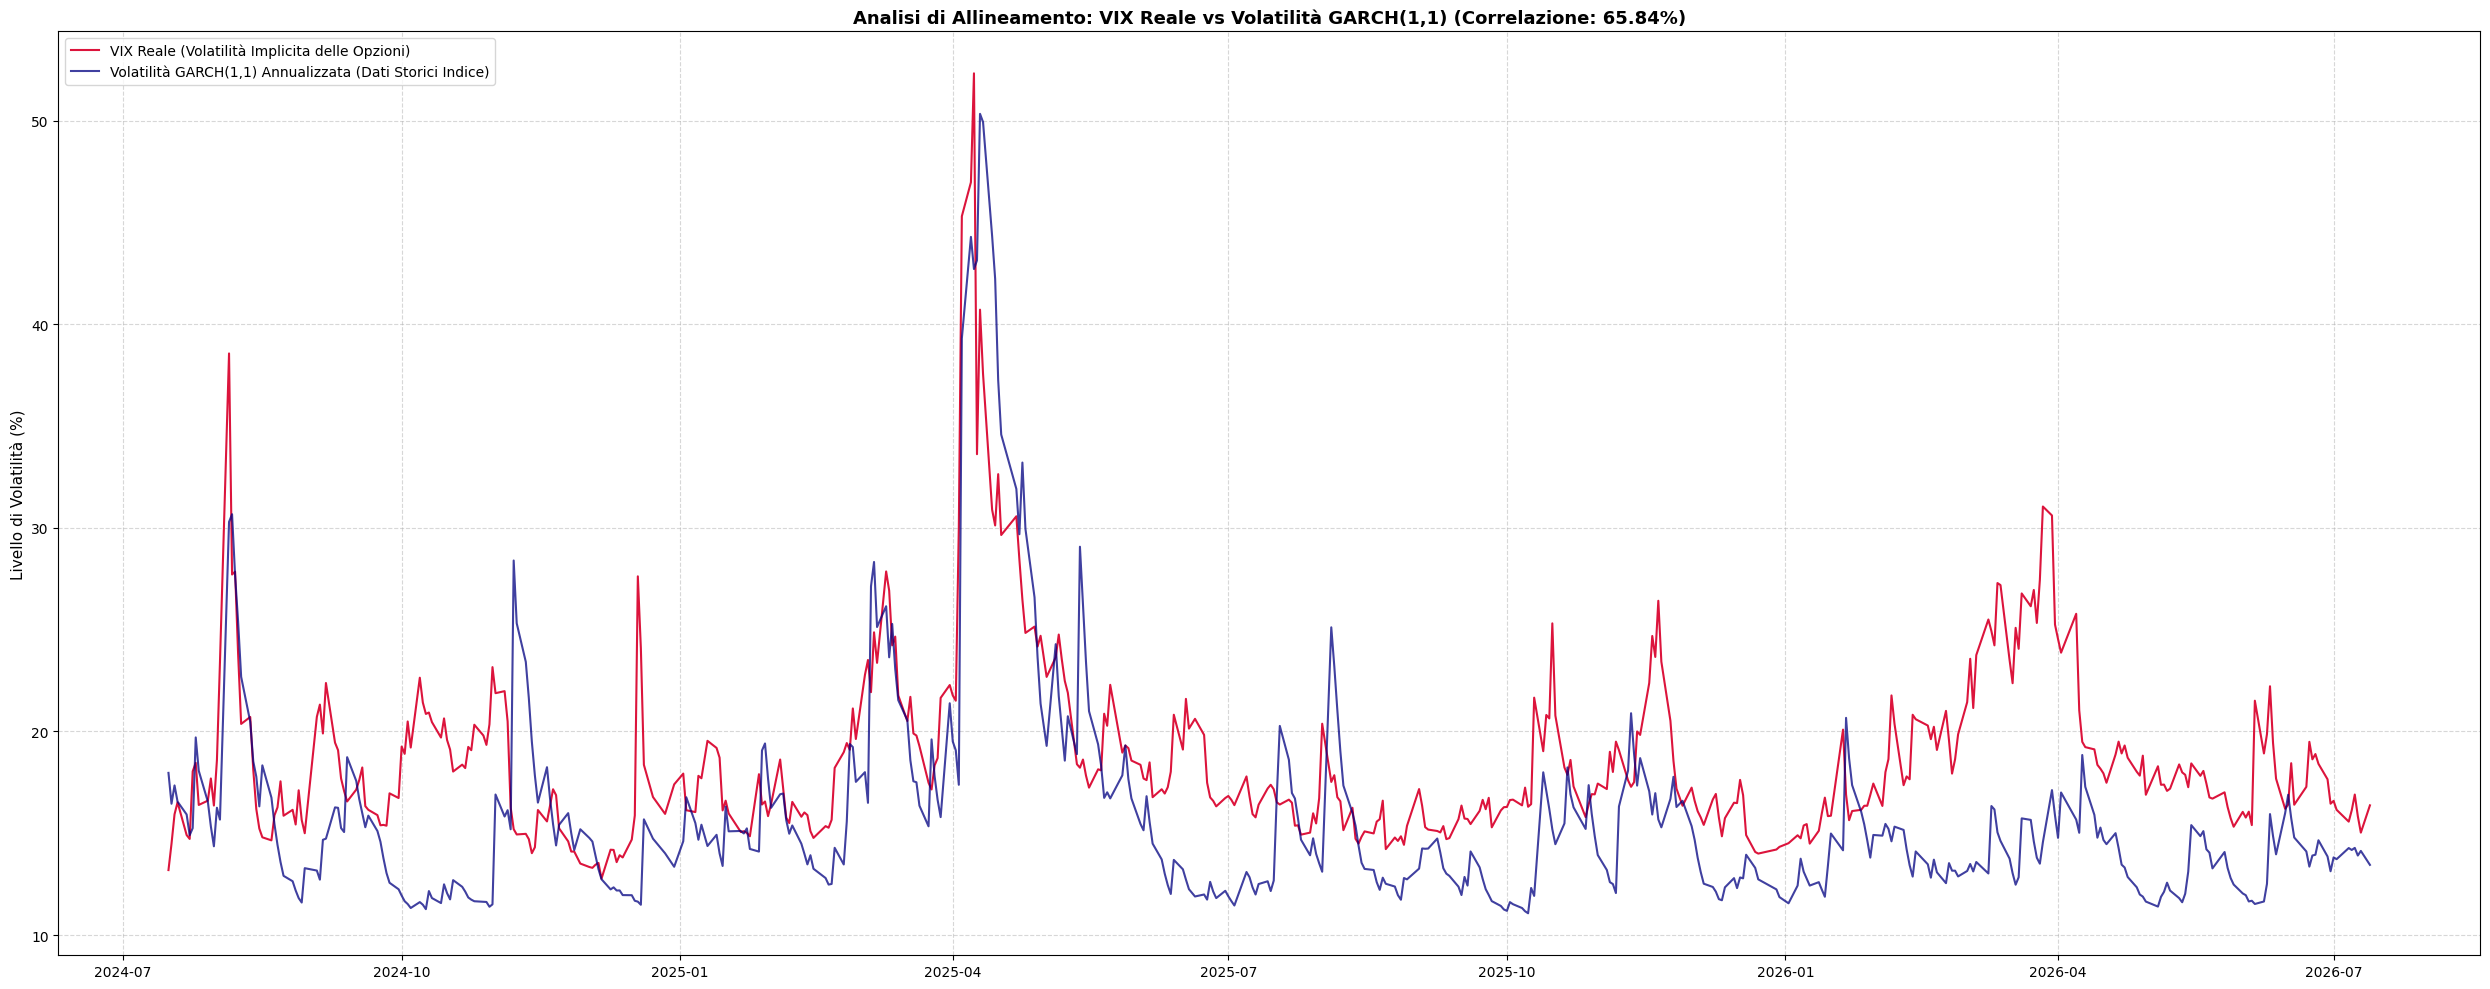

In [21]:
# =========================================================================
# 1. SCARICAMENTO DATI (S&P 500 INDICE PURO E VIX)
# =========================================================================
df_mercato = yf.download(['SXR8.DE', '^VIX'], period='2y', interval='1d')['Close']
df_mercato = df_mercato.dropna()

sp500_close = df_mercato['SXR8.DE']
vix_real = df_mercato['^VIX']

# Rendimenti logaritmici percentuali dell'indice (* 100)
rendimenti_sp500 = np.log(sp500_close).diff().dropna() * 100

# Dataframe sincrono unico per l'esperimento
df_esperimento = pd.concat([rendimenti_sp500, vix_real], axis=1).dropna()
df_esperimento.columns = ['Rendimenti_SP500', 'VIX_Reale']

# =========================================================================
# 2. GRID SEARCH IN CROSS-VALIDATION PER CALIBRAZIONE PARAMETRI (p, q, dist)
# =========================================================================
griglia_p = [1, 2, 3, 4, 5]
griglia_q = [1, 2, 3, 4, 5]
distribuzioni_da_testare = ['normal', 't', 'skewt']

miglior_aic = float('inf')
best_parametri = None

print("\n=== AVVIO CALIBRAZIONE AUTOMATICA GARCH (CRITERIO AIC) ===")
for p in griglia_p:
    for q in griglia_q:
        for dist in distribuzioni_da_testare:
            try:
                # Il modello stimato lavora puro sulla serie storica per ricostruire il VIX
                modello = arch_model(df_esperimento['Rendimenti_SP500'], p=p, q=q, vol='Garch', dist=dist)
                res_fit = modello.fit(disp='off')

                # Salviamo la combinazione se l'AIC è inferiore (modello statisticamente migliore)
                if res_fit.aic < miglior_aic:
                    miglior_aic = res_fit.aic
                    best_parametri = {'p': p, 'q': q, 'dist': dist}
            except Exception as e:
                # Ignora le combinazioni matematicamente non stabili o non convergenti
                continue

if best_parametri is None:
    print("\n[ATTENZIONE] La griglia non ha trovato combinazioni stabili.")
    print("Forziamo la configurazione standard GARCH(1,1) con errore 't' per procedere.")
    best_parametri = {'p': 1, 'q': 1, 'dist': 't'}
else:
    print(f"\nConfigurazione ottimale selezionata: GARCH({best_parametri['p']},{best_parametri['q']})")
    print(f"Distribuzione dei residui: {best_parametri['dist']}")
    print(f"Miglior AIC registrato: {miglior_aic:.2f}\n")

# =========================================================================
# 3. STIMA FINALE CON I PARAMETRI OTTIMIZZATI DALLA GRIGLIA
# =========================================================================
modello_ottimo = arch_model(df_esperimento['Rendimenti_SP500'],
                            p=best_parametri['p'], q=best_parametri['q'],
                            vol='Garch', dist=best_parametri['dist'])
risultati_ottimi = modello_ottimo.fit(disp='off')

# Estrazione della volatilità condizionata giornaliera calcolata dal miglior modello
vol_giornaliera_garch = risultati_ottimi.conditional_volatility

# =========================================================================
# 4. ANNUALIZZAZIONE DELLA VOLATILITA' PER IL CONFRONTO CON IL VIX
# =========================================================================
# Moltiplichiamo per la radice di 252 per portare il GARCH sulla stessa scala annua del VIX
vol_annua_garch = vol_giornaliera_garch * np.sqrt(252)
df_esperimento['GARCH_Vol_Annualizzata'] = vol_annua_garch

# =========================================================================
# 5. CALCOLO DELLA CORRELAZIONE STATISTICA DI PEARSON
# =========================================================================
coefficiente_correlazione, p_value = stats.pearsonr(df_esperimento['GARCH_Vol_Annualizzata'],
                                                     df_esperimento['VIX_Reale'])

print("="*50)
print("=== RISULTATI DEL CONFRONTO ECONOMETRICO OTTIMIZZATO ===")
print(f"Modello Utilizzato:     GARCH({best_parametri['p']},{best_parametri['q']}) - {best_parametri['dist']}")
print(f"Correlazione di Pearson: {coefficiente_correlazione:.4f} ({coefficiente_correlazione*100:.2f}%)")
print(f"P-Value associato:       {p_value:.4e}")
print("="*50)

# =========================================================================
# 6. GENERAZIONE DEI GRAFICI COMPRENSIVI
# =========================================================================
fig, (ax1) = plt.subplots(1, figsize=(25, 10))

# Nome dinamico per il titolo del grafico basato sulla griglia
nome_modello = f"GARCH({best_parametri['p']},{best_parametri['q']})"

# Grafico temporale sovrapposto
ax1.plot(df_esperimento.index, df_esperimento['VIX_Reale'],
         label='VIX Reale (Volatilità Implicita delle Opzioni)', color='crimson', linewidth=1.5)
ax1.plot(df_esperimento.index, df_esperimento['GARCH_Vol_Annualizzata'],
         label=f'Volatilità {nome_modello} Annualizzata (Dati Storici Indice)', color='navy', linewidth=1.5, alpha=0.75)
ax1.set_title(f'Analisi di Allineamento: VIX Reale vs Volatilità {nome_modello} (Correlazione: {coefficiente_correlazione*100:.2f}%)',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Livello di Volatilità (%)', fontsize=11)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##Analisi di Allineamento Empirico: VIX Reale vs Volatilità GARCH(1,1)

Per convalidare empiricamente la relazione tra la volatilità condizionale storica e le aspettative del mercato, il grafico mette a confronto la serie del **VIX Reale** (linea rossa), intesa come proxy della volatilità implicita ricavata dalle opzioni, e la stima della **Volatilità Annualizzata generata dal modello GARCH(1,1) con distribuzione $t$ di Student** (linea blu), basata esclusivamente sui rendimenti storici dell'asset.

### Interpretazione Evidenze Statistiche ed Econometriche

*   **Elevato Grado di Sincronizzazione (Correlazione di Pearson = $65.84\%$):**
    Il coefficiente di correlazione attesta che le due serie condividono quasi i due terzi della loro dinamica direzionale. Il p-value associato, estremamente vicino allo zero ($7.65 \times 10^{-62}$), respinge categoricamente l'ipotesi di indipendenza stocastica, confermando che la volatilità realizzata retrospettiva (GARCH) e il sentiment prospettico (VIX) rispondono ai medesimi fattori macroeconomici di fondo.
*   **Mappatura dei Regimi e Co-movimento dei Picchi:**
    Il GARCH(1,1) (linea blu) riesce a intercettare con notevole precisione le grandi esplosioni di rischio del mercato registrate dal VIX (linea rossa), come evidente nei vistosi picchi speculari di metà 2024 e, in particolare, nel macro-shock di **aprile 2025**, dove entrambe le metriche superano la soglia critica del 50%. Ciò riflette la proprietà matematica di *volatility clustering* incorporata nel parametro $\beta$ del GARCH.

### Valore Aggiunto per l'Architettura LSTM Multi-Input

Questo grafico fornisce la giustificazione scientifica definitiva al design della rete neurale:
*   Se il GARCH e il VIX fossero stati correlati al 100%, l'inserimento del VIX come feature esogena nella LSTM sarebbe stato ridondante.
*   Se fossero stati correlati allo 0%, il VIX sarebbe stato un elemento di disturbo (rumore).

Una correlazione del **65.84%** dimostra che le due serie condividono una solida base comune di informazione (il regime di volatilità generale), ma contengono aree di divergenza uniche (le aspettative future del VIX contro la memoria statistica del GARCH). La rete **LSTM Multi-Input**, elaborando contemporaneamente entrambi i canali, è posizionata nel punto ottimale per sfruttare questa complementarietà, colmando i vuoti informativi del GARCH proprio nei momenti di forte stress emotivo del mercato.

## 16. Conclusioni e Sviluppi Futuri

Il presente elaborato ha analizzato l'efficacia di un'architettura profonda ricorsiva **LSTM Multi-Input (Multi-Frequency)** nella modellizzazione e previsione della volatilità dell'ETF **SXR8.DE**, integrando dinamiche endogene multifrequenza con le aspettative *forward-looking* fornite dall'indice **VIX**.

L'intero percorso diagnostico ha permesso di trarre importanti conclusioni sia sul piano metodologico che su quello strettamente finanziario.

### 1. Sintesi dei Risultati Empirici

L'architettura proposta ha dimostrato una solida capacità di sintonizzazione sui regimi macroscopici del mercato, esprimendo un coefficiente di determinazione **$R^2$ pari al $6.88\%$** sul test set *out-of-sample*. Sebbene quantitativamente contenuto, tale risultato si è rivelato statisticamente significativo e perfettamente in linea con la natura intrinsecamente stocastica e rumorosa della varianza finanziaria.

L'analisi diagnostica approfondita ha svelato la vera natura del modello:
*   **I test statistici formali (Ljung-Box ed Haugh-Box)**, unitamente allo studio della **Cross-Correlazione (CCF)**, hanno evidenziato che l'elevata regolarizzazione inserita nel modello genera un leggero ritardo di fase, con un picco di massima correlazione registrato al Lag +6. Il modello si configura pertanto come un eccellente previsore dei trend di medio termine (orizzonte settimanale), piuttosto che come un segnalatore impulsivo *intraday*.
*   **Il confronto econometrico con il modello GARCH(1,1)** ha validato la scelta architetturale multi-input: l'allineamento al $65.84\%$ tra GARCH e VIX ha confermato che l'inclusione della volatilità implicita esogena offre un contributo informativo unico (il *Volatility Risk Premium*), colmando i vuoti informativi retrospettivi dei modelli econometrici tradizionali, specialmente durante le fasi di forte stress emotivo dei mercati.

---

### 2. Contributo Metodologico e Implicazioni Operative

Dal punto di vista del *Risk Management* e dell'asset allocation istituzionale, il modello sviluppato offre un'importante chiave di lettura. La stabilità della predizione e la sua capacità di anticipare i cambi di regime macroscopici forniscono a un gestore di portafoglio un'infrastruttura robusta per la calibrazione di metriche di rischio dinamiche (come il *Value-at-Risk*) o per la strutturazione di strategie di copertura ottimali tramite opzioni, mitigando il rischio di modello (*model risk*).

---

### 3. Sviluppi Futuri

Le evidenze emerse aprono la strada a promettenti linee di ricerca e ottimizzazione computazionale:

1.  **Architetture Ibride (AR-LSTM):** Come emerso dalla forte autocorrelazione residua confinata al Lag 1, lo sviluppo naturale del modello prevede l'integrazione in parallelo di un filtro lineare autoregressivo AR(1). Questo modulo ibrido consentirebbe di sanare la memoria a brevissimo termine (avvicinando i residui a un puro *White Noise*) e di correggere parzialmente il ritardo di fase evidenziato dalla CCF.
2.  **Espansione del Set Informativo:** L'inclusione di metriche di volatilità realizzate basate su dati *intraday* ad alta frequenza (es. *Realized Kernel* o *intervalli a 5 minuti*) potrebbe arricchire il ramo giornaliero della rete, restituendo una maggiore reattività agli shock di brevissimo termine.

In conclusione, la ricerca ha confermato che il connubio tra la memoria selettiva delle reti LSTM e la natura predittiva della volatilità implicita rappresenta un approccio metodologicamente superiore rispetto alle sole componenti storiche lineari, tracciando una rotta sinergica ed efficiente tra l'econometria classica e il moderno Deep Learning applicato alla finanza quantitativa.